In [ ]:
setwd("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/bulk/hahn_2023/cortex")

library(dplyr)

source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/marker_vs_mod_corr.R")
source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/module_projection_fxns.R")


In [ ]:
summary_type <- "PC1"

In [4]:
marker_genes_list <- readRDS("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/marker_genes/AI/Claude_cortical_markers_mouse.RDS")

bulk_expr <- fread("data/cleaned/ModSeed/hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned.csv", data.table=FALSE)

network_dir <- "hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules"

In [ ]:
sc_data_source <- "yao_2021_ACA_MOp_VISp_STAR_gene_counts_normalized"

sc_expr <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/data/yao_2021_ACA_MOp_VISp_STAR_gene_counts.csv", data.table=FALSE)
sampleinfo <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA_MOp_VISp/data/yao_2021_ACA_MOp_VISp_STAR_sampleinfo.csv", data.table=FALSE)
colnames(sc_expr)[1] <- "Gene"


total_expr <- colSums(sc_expr[,-1])
sc_expr_norm <- sweep(sc_expr[,-1], MARGIN=2, FUN="/", STATS=total_expr) * 1e4
sc_expr_norm <- data.frame(Gene=sc_expr[,1], sc_expr_norm) 

ctype_assignment_vec <- sampleinfo$subclass_label

In [5]:
colnames(bulk_expr)[1] <- "Gene"

mean_expr <- data.frame(
    Index=1:nrow(bulk_expr), 
    Gene=bulk_expr[,1], 
    Expr=rowMeans(bulk_expr[,-1])
)

mean_expr <- mean_expr %>%
    group_by(Gene) %>%
    slice_max(Expr, with_ties=FALSE)

bulk_expr <- bulk_expr[mean_expr$Index,]

marker_genes_list <- lapply(marker_genes_list, function(markers) {
    markers[markers %in% bulk_expr[,1]]
})

In [8]:
networks <- list.files(network_dir, pattern="signum", full.names=TRUE)
networks <- networks[lengths(lapply(networks, list.files)) > 0]

In [10]:
# Make sure order of samples matches FM output

modEigs <- fread(list.files(networks[1], pattern="eigen", full.names=TRUE), data.table=FALSE)
bulk_expr <- bulk_expr[,c(1, match(modEigs$Sample, colnames(bulk_expr)))]
all.equal(modEigs$Sample, colnames(bulk_expr)[-1])

[1] TRUE

In [ ]:
ctype_mod_corrs <- marker_vs_mod_corr(bulk_expr, networks,  marker_genes_list, summary_type)

In [ ]:
# ctype_mod_corrs$leadingEdge <- unlist(lapply(ctype_mod_corrs$leadingEdge, function(x) paste(x, collapse=", ")))

In [95]:
ctype_mod_corrs %>%
    group_by(Cell_type) %>%
    slice_max(Corr) %>%
    slice_min(padj) %>%
    arrange(padj)

Cell_type,Network,Mod,Corr,Top_kME_genes,ME_path,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
Oligo,Bicor-None_signum0.782_minSize6_merge_ME_0.93_17245,black,0.9894189,"Cnp, Mag, Gjc3, Plp1, Fa2h, Mbp, Mog, Ermn, Trf, Mobp, Ugt8a, Aspa, Cldn11, Nkx6-2, Ppp1r14a",hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules/Bicor-None_signum0.782_minSize6_merge_ME_0.93_17245/Module_eigengenes_06-03-16.csv,Oligo,2.577915e-17,2.577915e-17,1.07686819,0.9613144,2.851867,14,"Cnp, Mag, Plp1, Fa2h, Mbp, Mog, Ermn, Trf, Mobp, Ugt8a, Cldn11, Opalin, Enpp6"
Micro/PVM,Bicor-None_signum0.809_minSize6_merge_ME_0.93_17245,turquoise,0.9831563,"Ndrg2, Bcan, Bsg, Hexb, Fgfr3, Pla2g7, Snhg14, Aldoc, Scrib, Gad2, Flvcr1, Zfp335, Glul, Ccdc90b, Nsun6",hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules/Bicor-None_signum0.809_minSize6_merge_ME_0.93_17245/Module_eigengenes_05-25-47.csv,Micro/PVM,6.291117e-13,6.291117e-13,0.92142600,0.8509530,3.273230,16,"Hexb, P2ry12, Cx3cr1, Selplg, Csf1r, Tmem119, C1qc, C1qb, Sall1, C1qa, Ctss, Tyrobp, Aif1, Trem2, Spi1"
L4 IT,Bicor-None_signum0.795_minSize6_merge_ME_0.93_17245,tan,0.9724164,"Col26a1, Ntn5, Whrn, Igfn1, Hs6st3, Rskr, Plekha4, Lama4, Zfp648, Mmel1, Tshz3, Cux2, A330008L17Rik, Thbs2, Gm38285",hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules/Bicor-None_signum0.795_minSize6_merge_ME_0.93_17245/Module_eigengenes_05-43-31.csv,L4 IT,2.190209e-09,2.190209e-09,0.77493903,0.9673731,2.895347,6,"Whrn, Rorb, Rspo1, Scnn1a, Ctxn3, Thsd7a"
All GABAergic,Bicor-None_signum0.809_minSize8_merge_ME_0.93_17245,turquoise,0.9813029,"Ndrg2, Bsg, Bcan, Hexb, Fgfr3, Pla2g7, Snhg14, Aldoc, Scrib, Glul, Zfp335, Flvcr1, Gad2, Ccdc90b, Trpt1",hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules/Bicor-None_signum0.809_minSize8_merge_ME_0.93_17245/Module_eigengenes_05-27-26.csv,All GABAergic,8.201777e-09,8.201777e-09,0.74773966,0.9356304,2.914531,7,"Gad2, Gad1, Dlx1, Slc32a1, Dlx5, Dlx6, Dlx2"
Astro,Bicor-None_signum0.782_minSize4_merge_ME_0.93_17245,turquoise,0.9925311,"Ndrg2, Bcan, Pla2g7, Gad2, Bsg, Erbb4, Cx3cr1, Fgfr3, Sox9, P2ry12, Scrib, Aldoc, Csf1r, 1700030K09Rik, Ccdc90b",hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules/Bicor-None_signum0.782_minSize4_merge_ME_0.93_17245/Module_eigengenes_05-58-01.csv,Astro,1.700374e-08,1.700374e-08,0.73376199,0.7445307,2.892293,17,"Ndrg2, Pla2g7, Fgfr3, Sox9, Aldoc, Slc1a3, Gja1, Apoe, Glul, Aldh1l1, Slc1a2, Slc7a10, Acsl6, S100b, Aqp4"
All Neuronal,Bicor-None_signum0.782_minSize4_merge_ME_0.93_17245,blue,0.9769614,"Rbfox3, Acsl6, Syt1, Snap25, Kcnc1, Mafb, Fn3krp, Cck, Gpsm2, Slc1a2, Esam, Haus3, Nrgn, Rimbp2, Panx2",hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules/Bicor-None_signum0.782_minSize4_merge_ME_0.93_17245/Module_eigengenes_05-58-01.csv,All Neuronal,3.579609e-07,3.579609e-07,0.67496286,0.8646323,2.669383,9,"Rbfox3, Syt1, Snap25, Nrgn, Tubb3, Thy1, Eno2, Stmn2"
OPC,Bicor-None_signum0.795_minSize3_merge_ME_0.93_17245,red,0.9761610,"Cnr1, Slc6a7, Sst, Tmem200a, Zdhhc12, Srgap1, Mgat4c, Tmcc3, Gm37107, Mettl27, Tril, Stmn2, Skap2, Shtn1, Ednrb",hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules/Bicor-None_signum0.795_minSize3_merge_ME_0.93_17245/Module_eigengenes_05-29-44.csv,OPC,5.662020e-07,5.662020e-07,0.65944440,0.8330723,2.624642,10,"Olig1, Bcan, Cspg4, Olig2, Vcan, Ptprz1, Pdgfra, Gpr17, Nkx2-2, Sox10"
Endo,Bicor-None_signum0.795_minSize10_merge_ME_0.93_17245,turquoise,0.9669850,"Ndrg2, Bsg, Bcan, Hexb, Glul, Snhg14, Fgfr3, Aldoc, Zfp335, Flvcr1, Aldh1l

In [96]:
top_mods_df <- ctype_mod_corrs %>%
    group_by(Cell_type) %>%
    slice_max(Corr) %>%
    slice_min(padj)

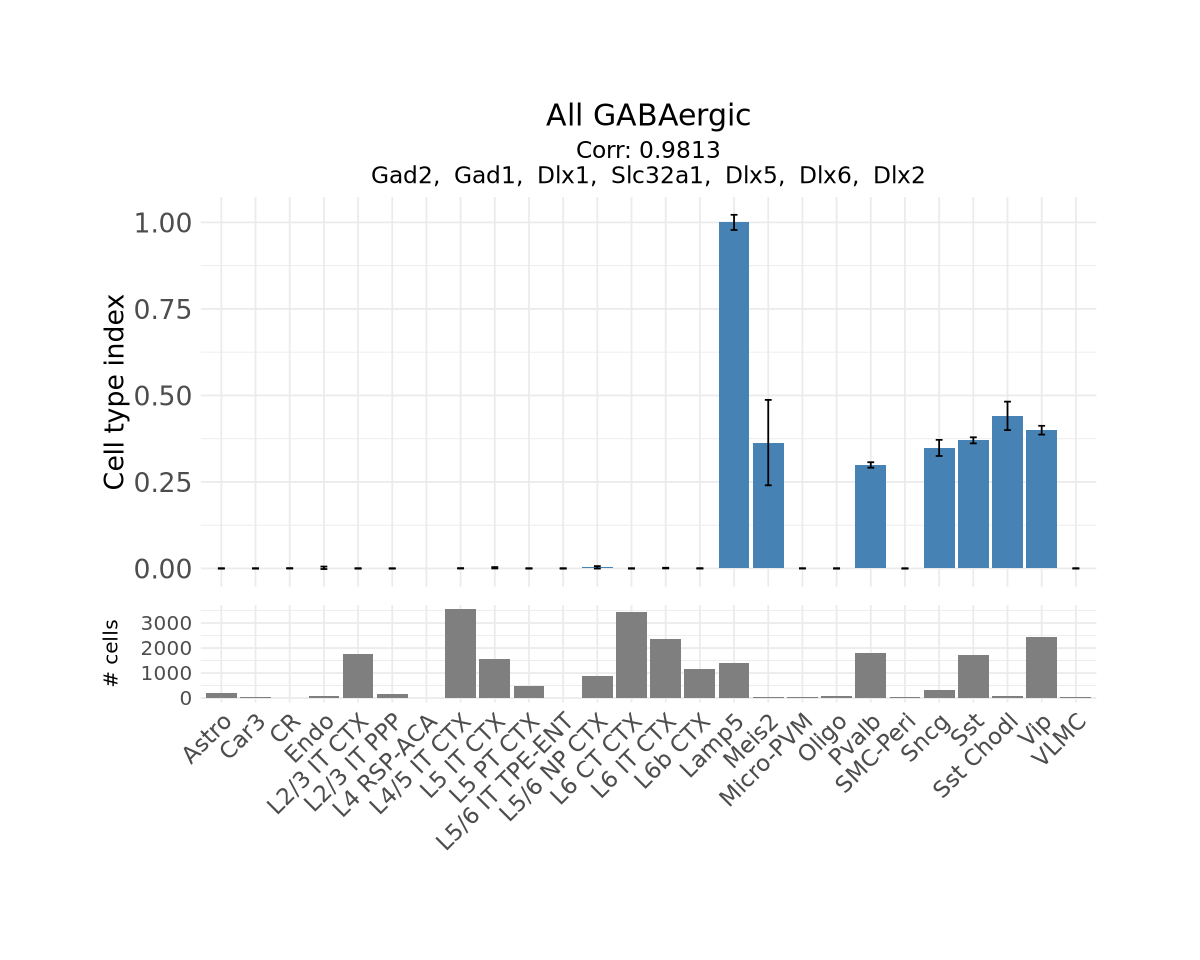

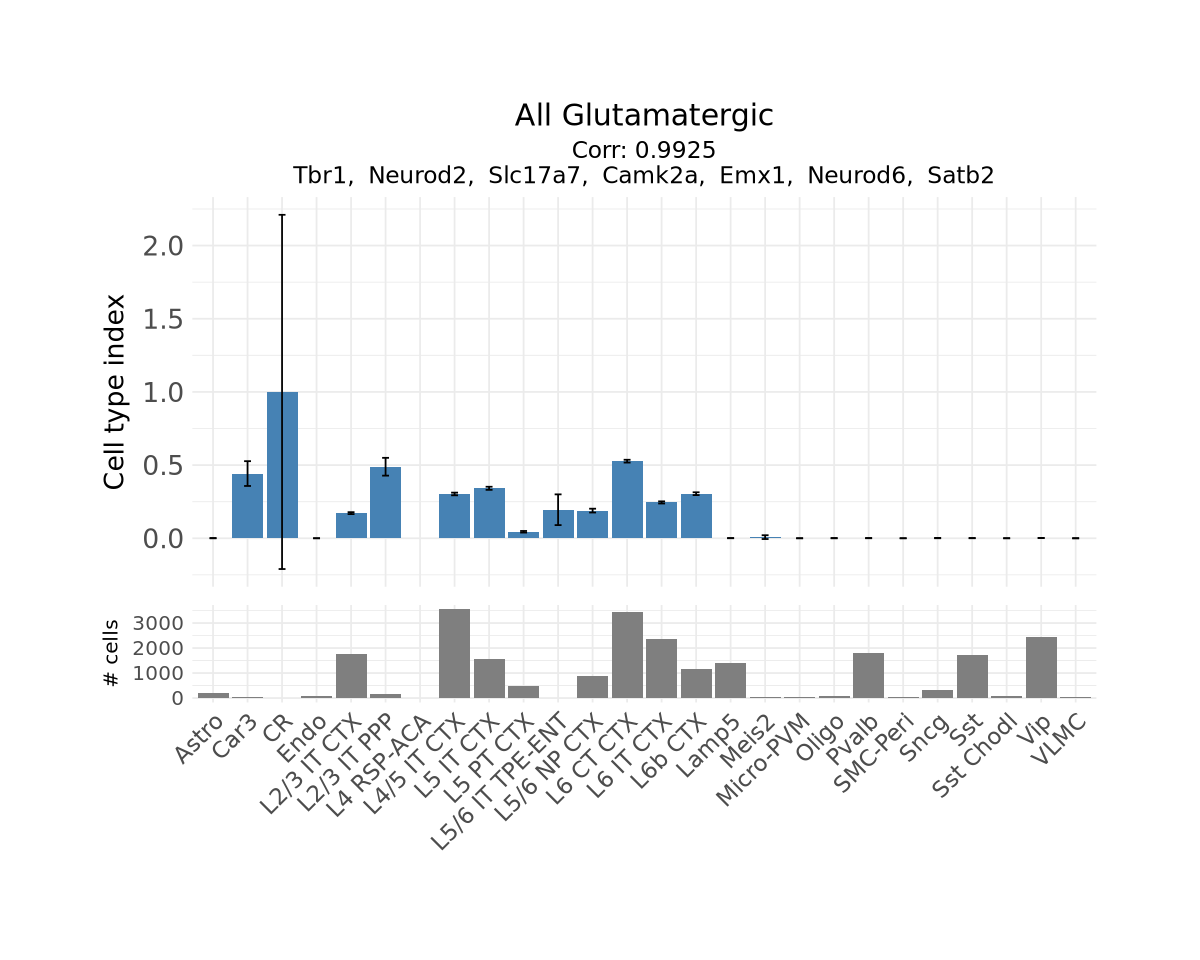

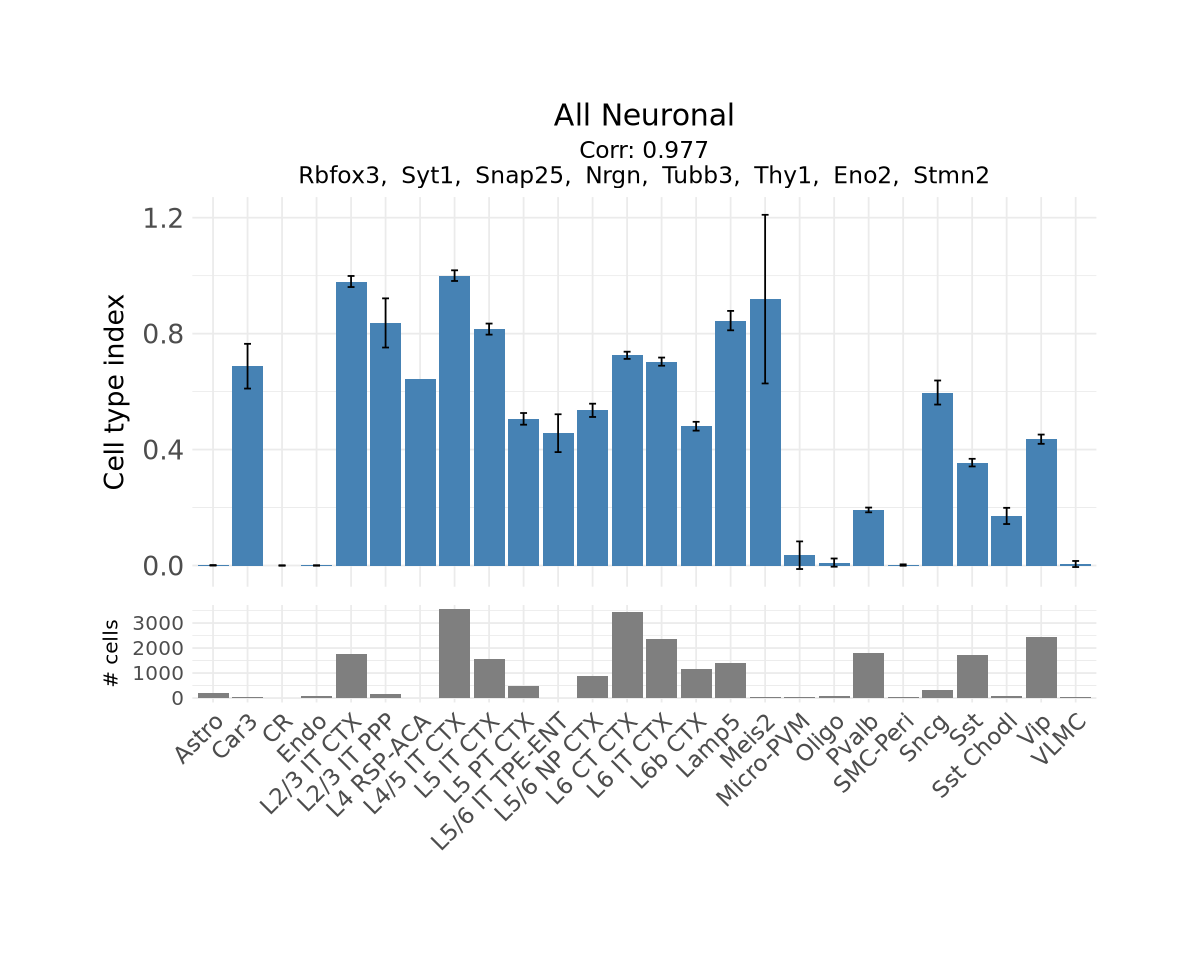

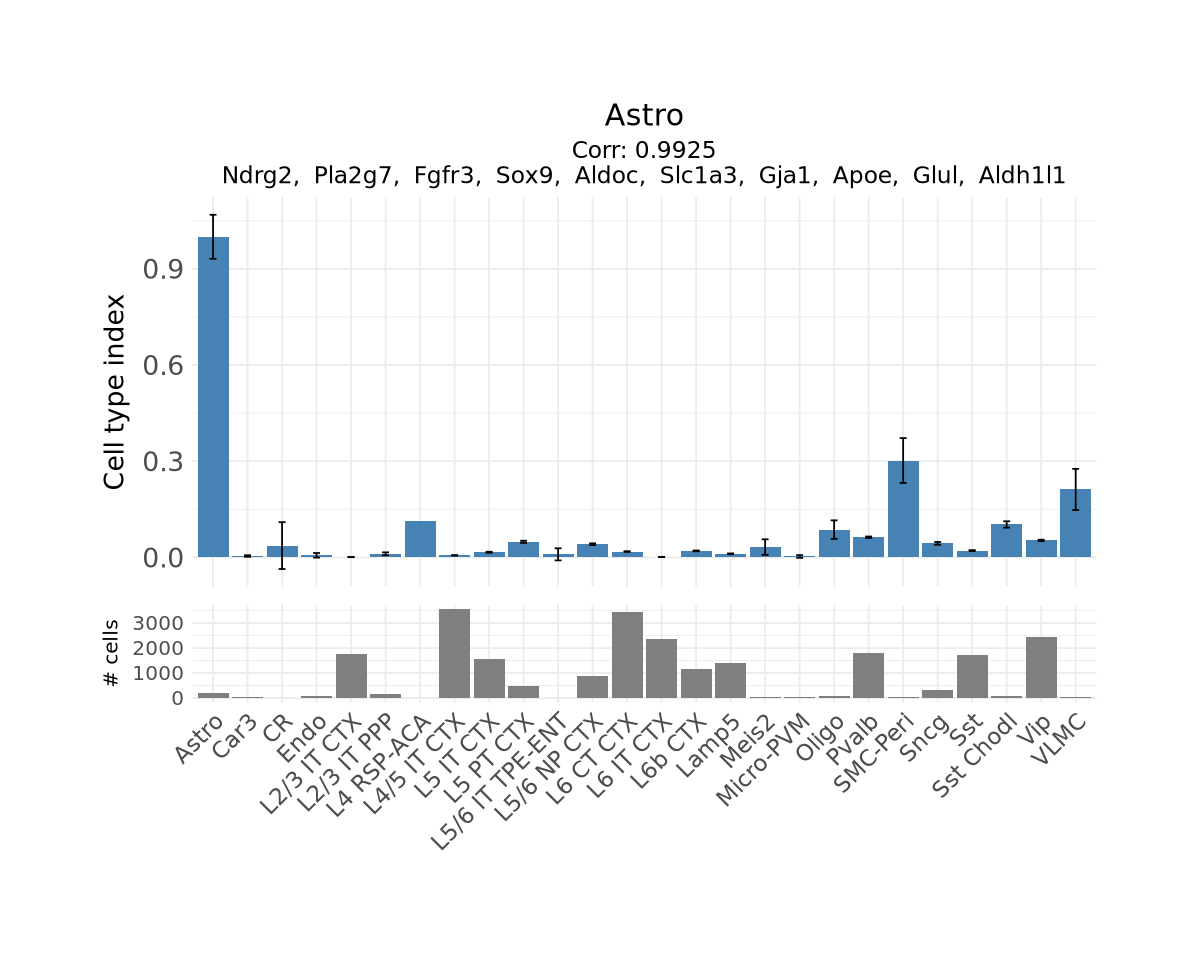

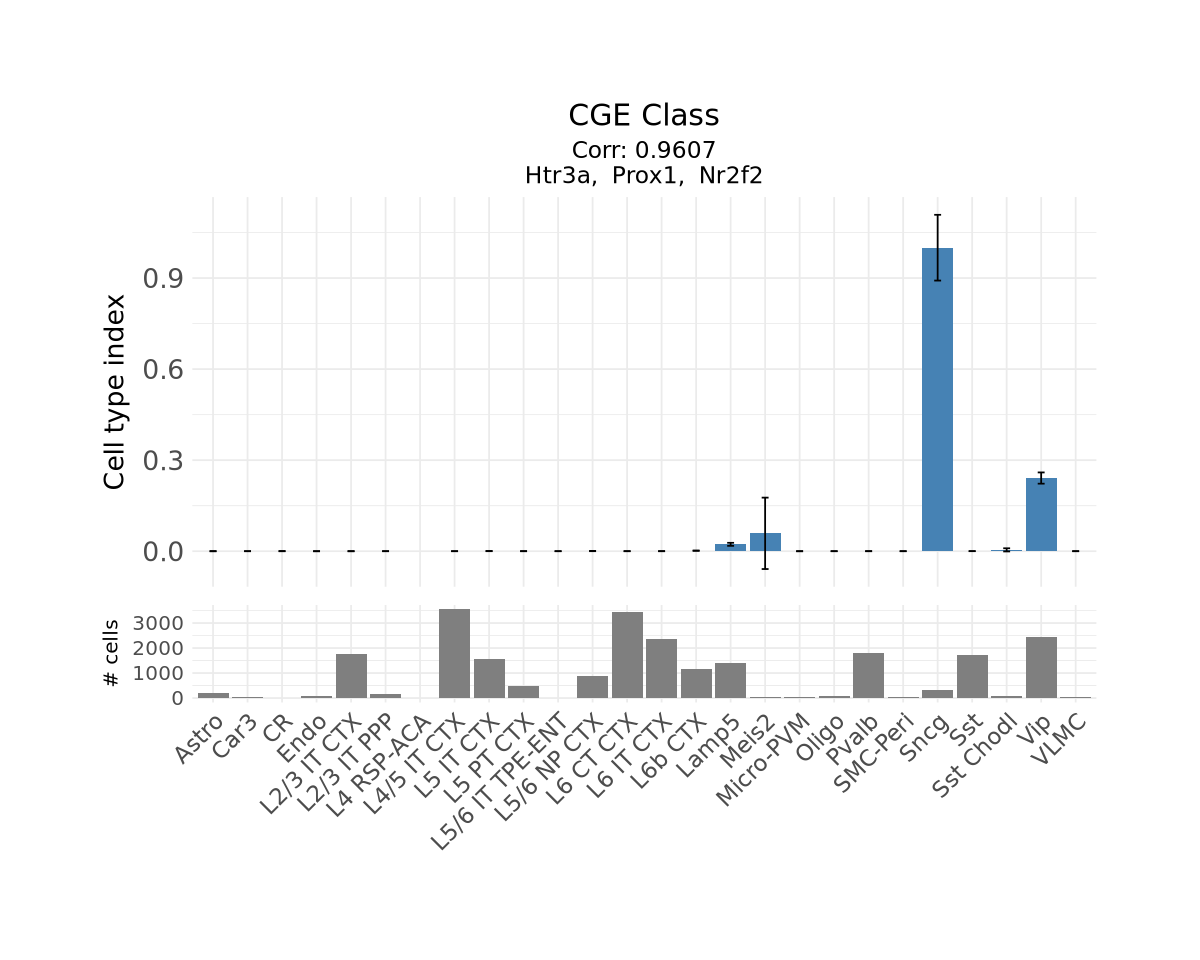

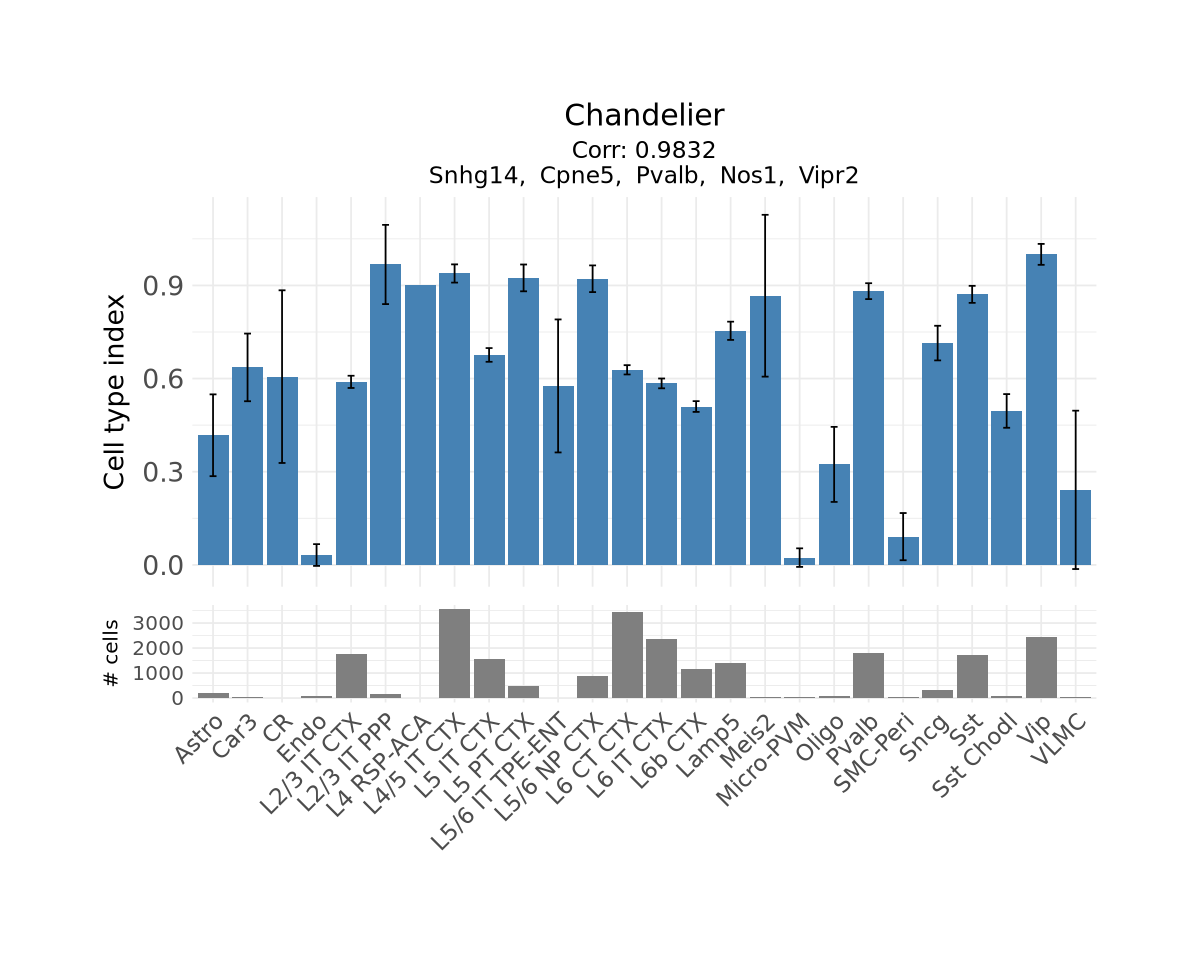

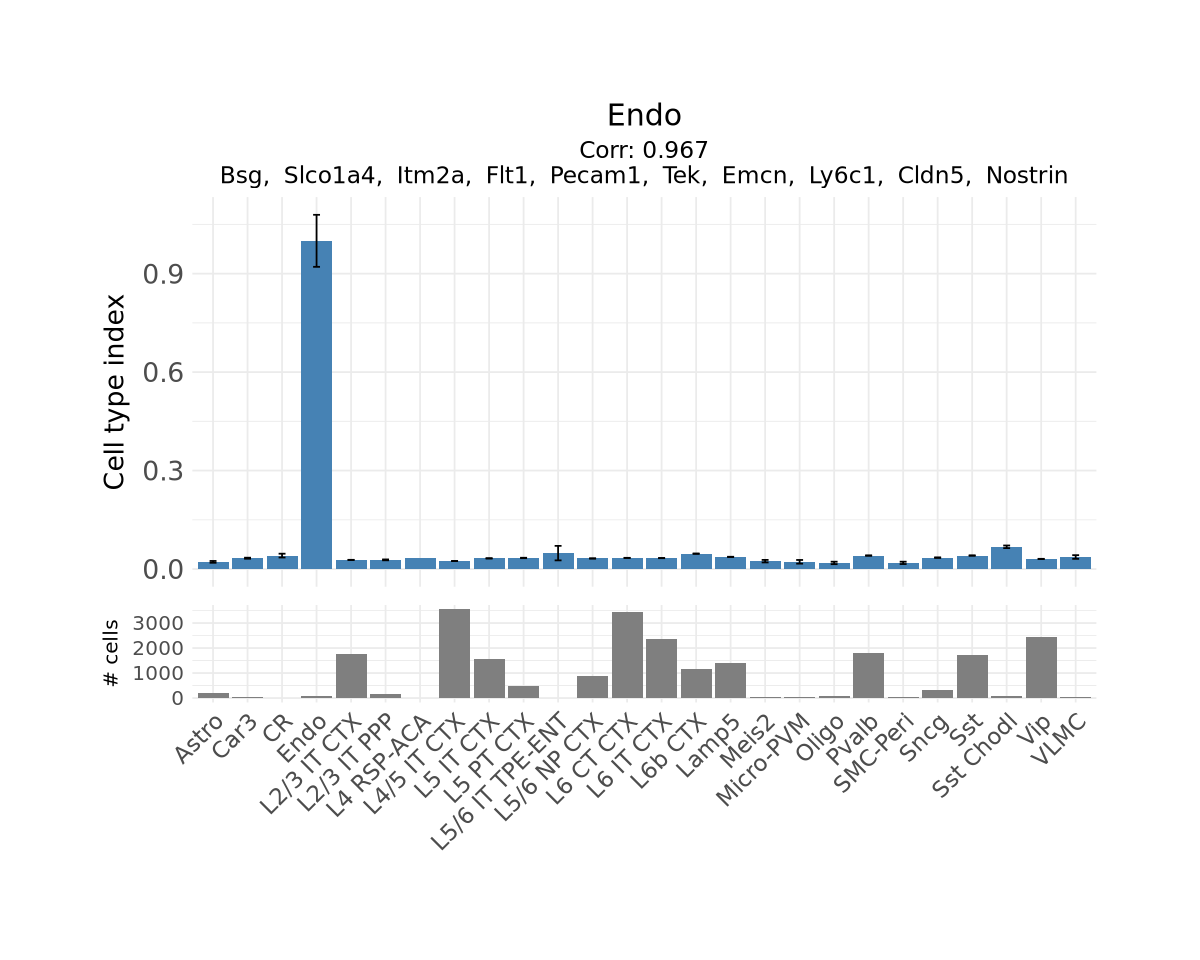

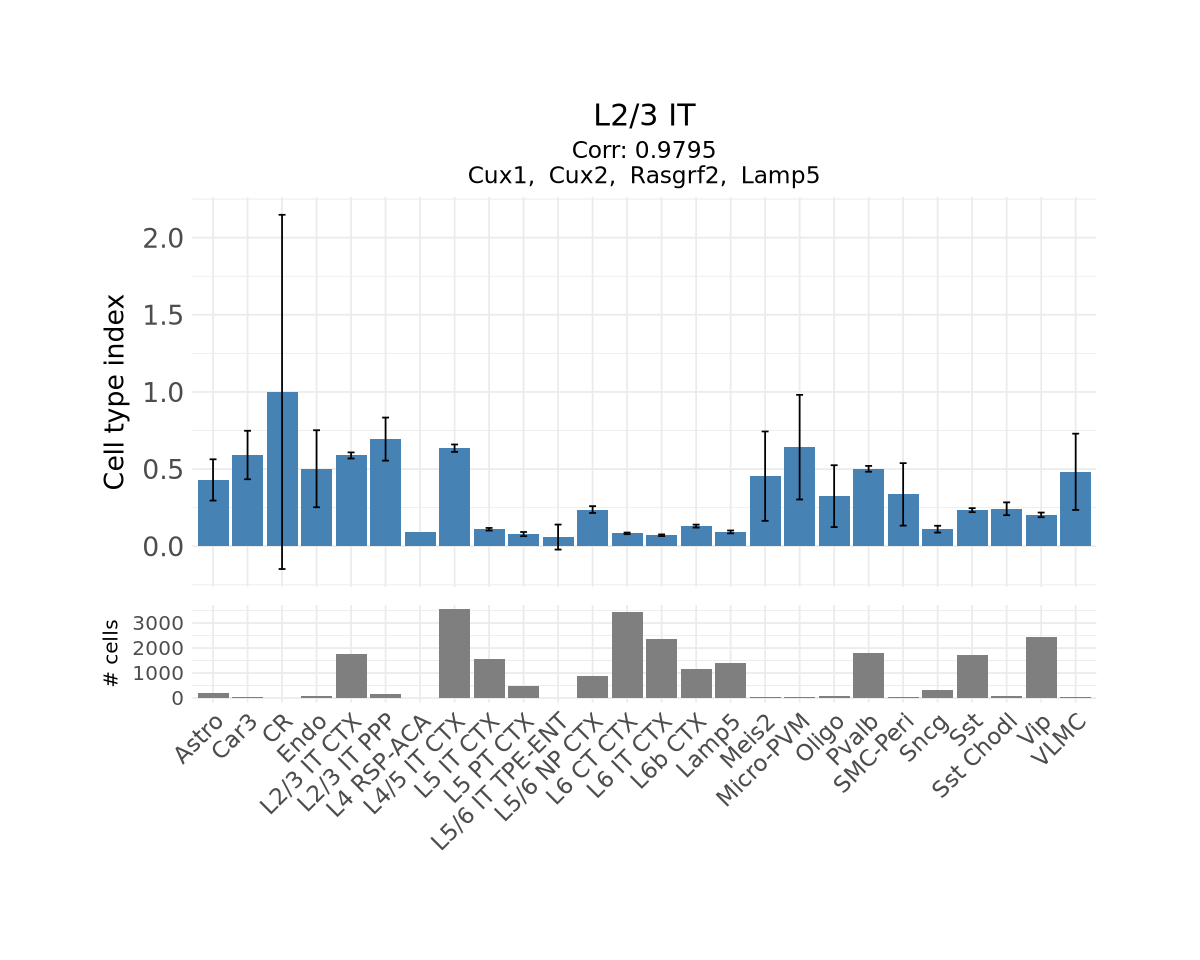

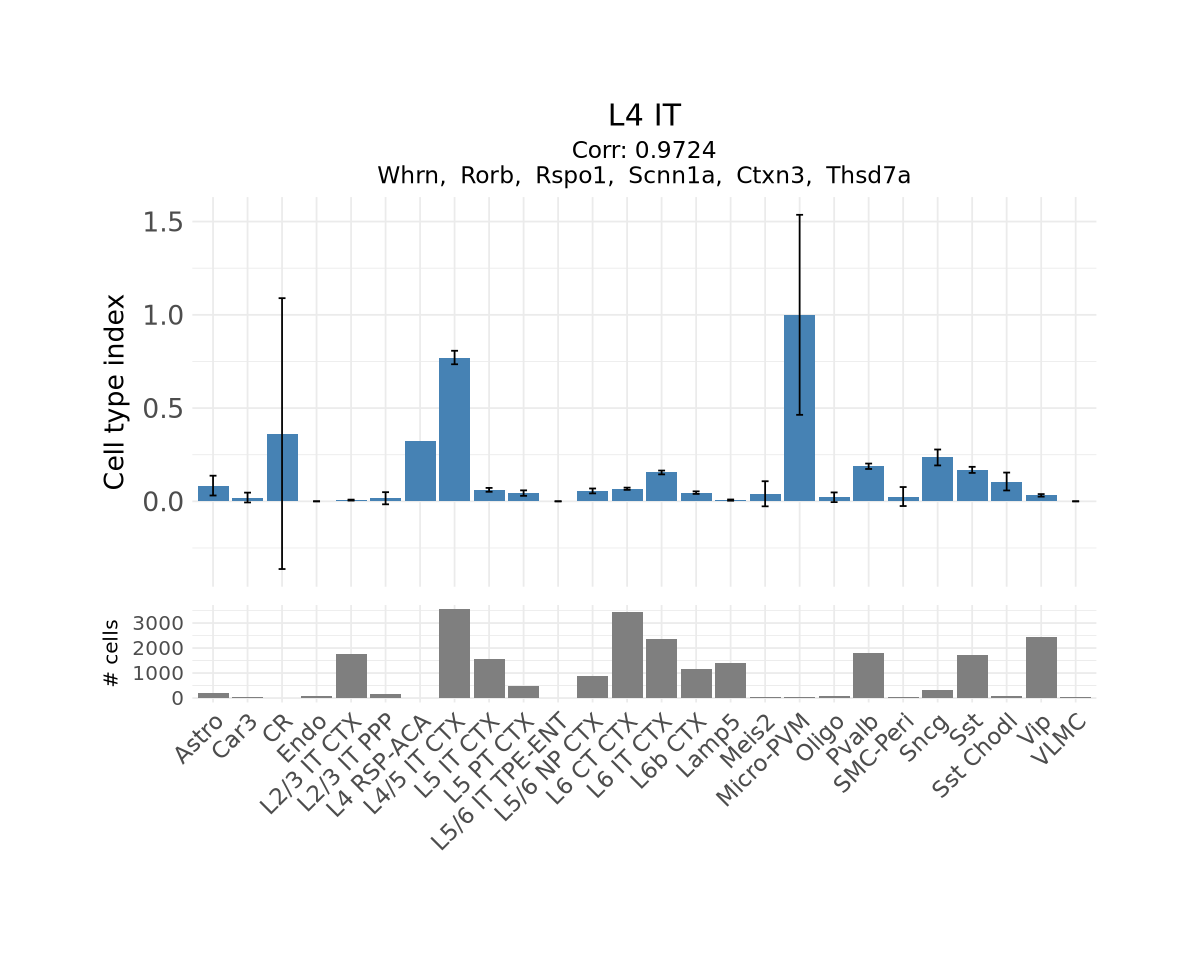

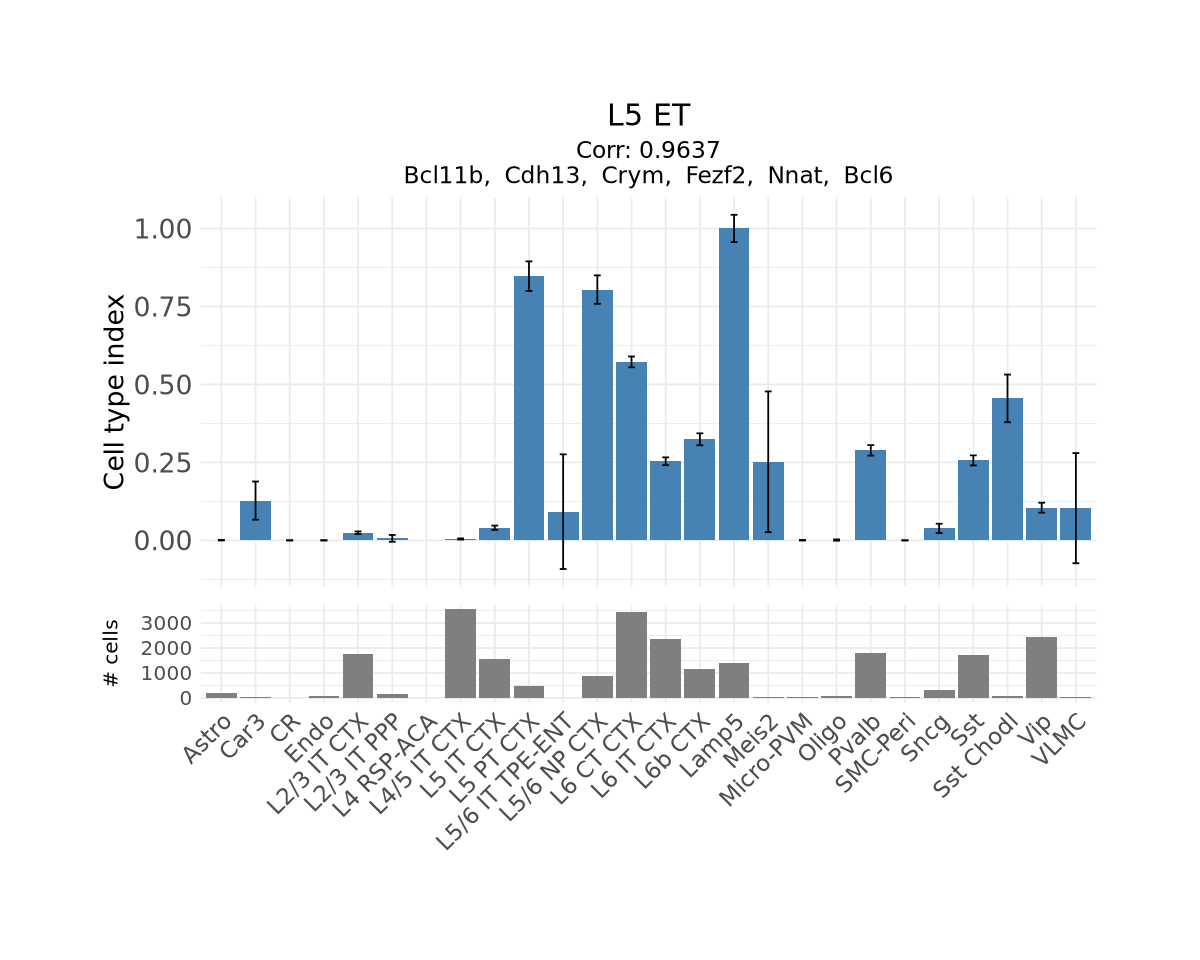

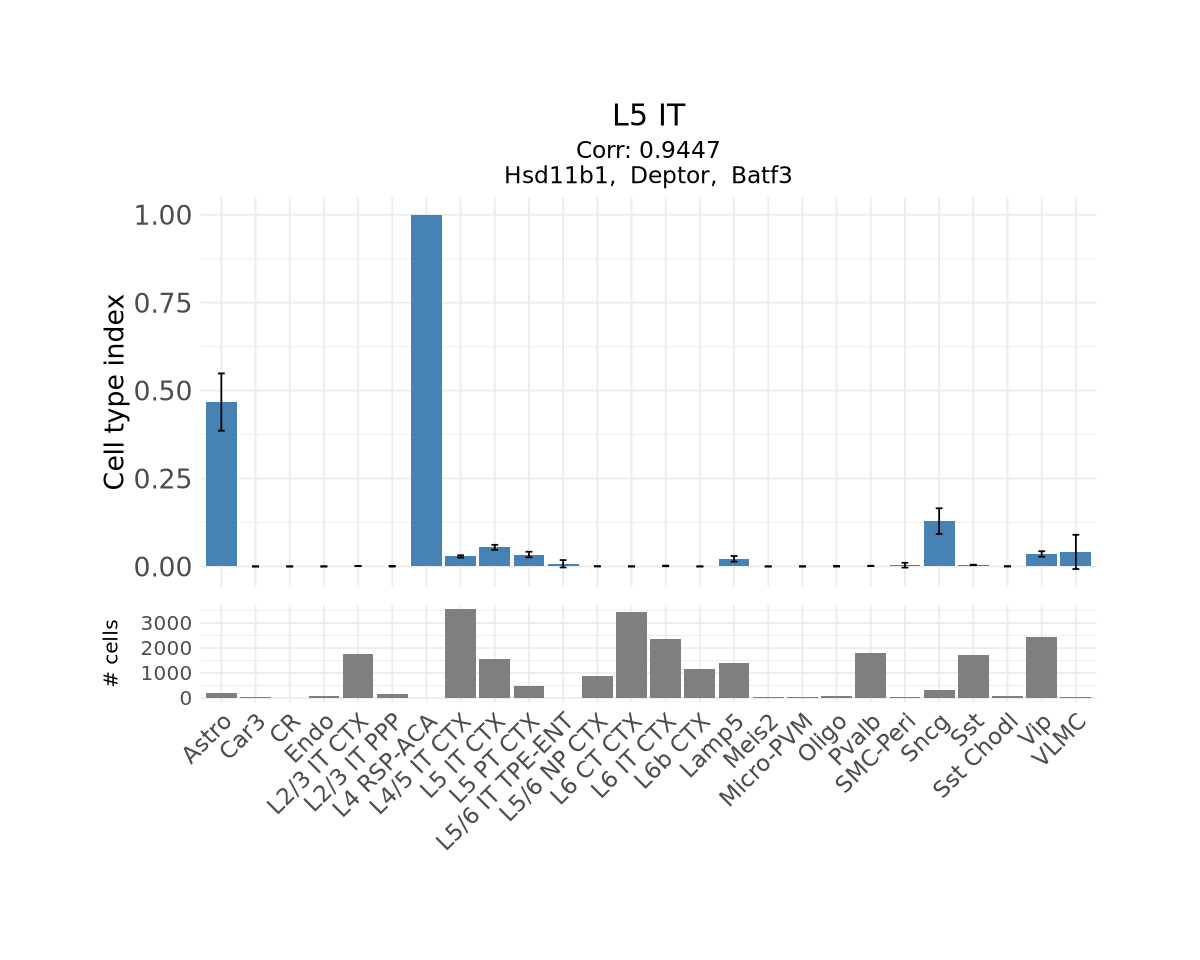

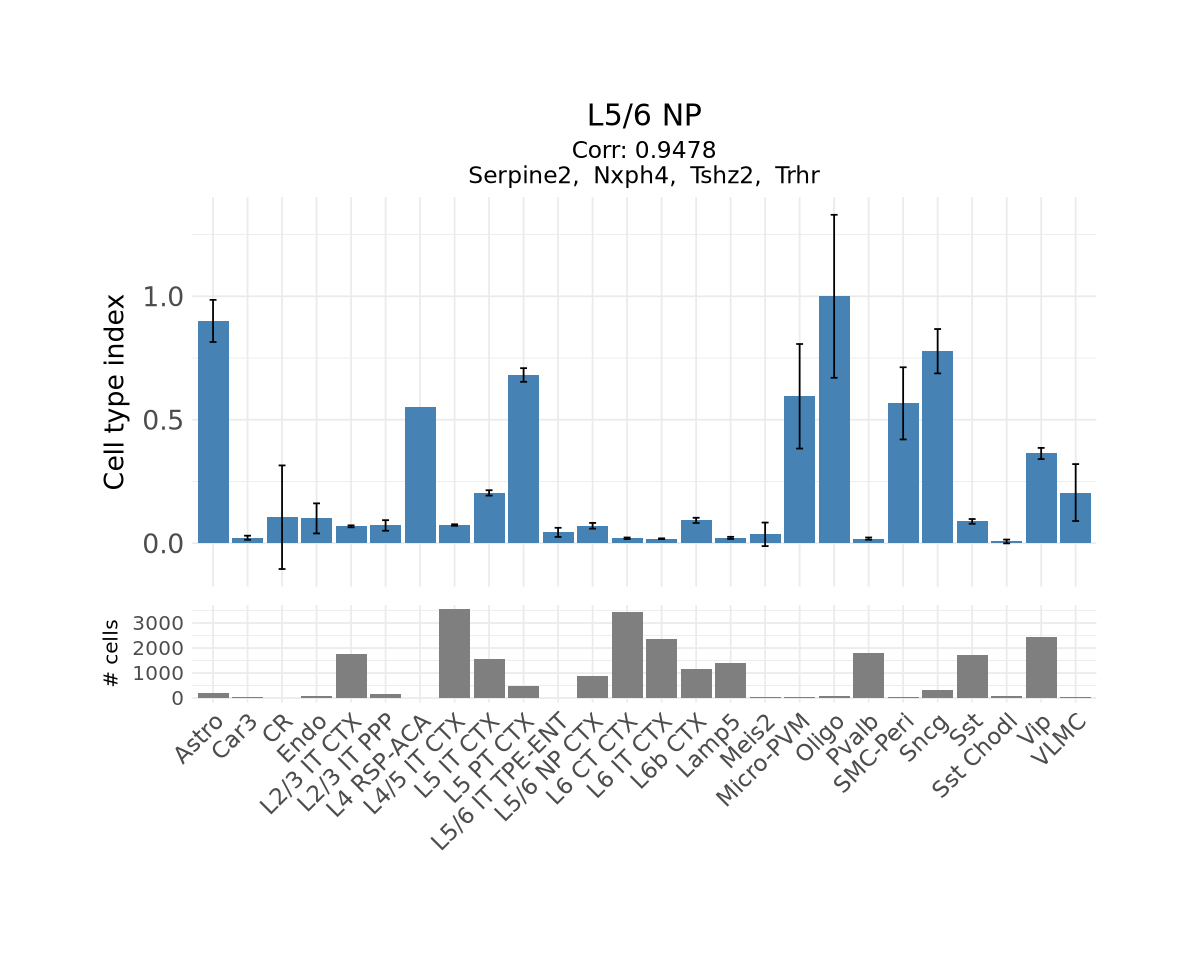

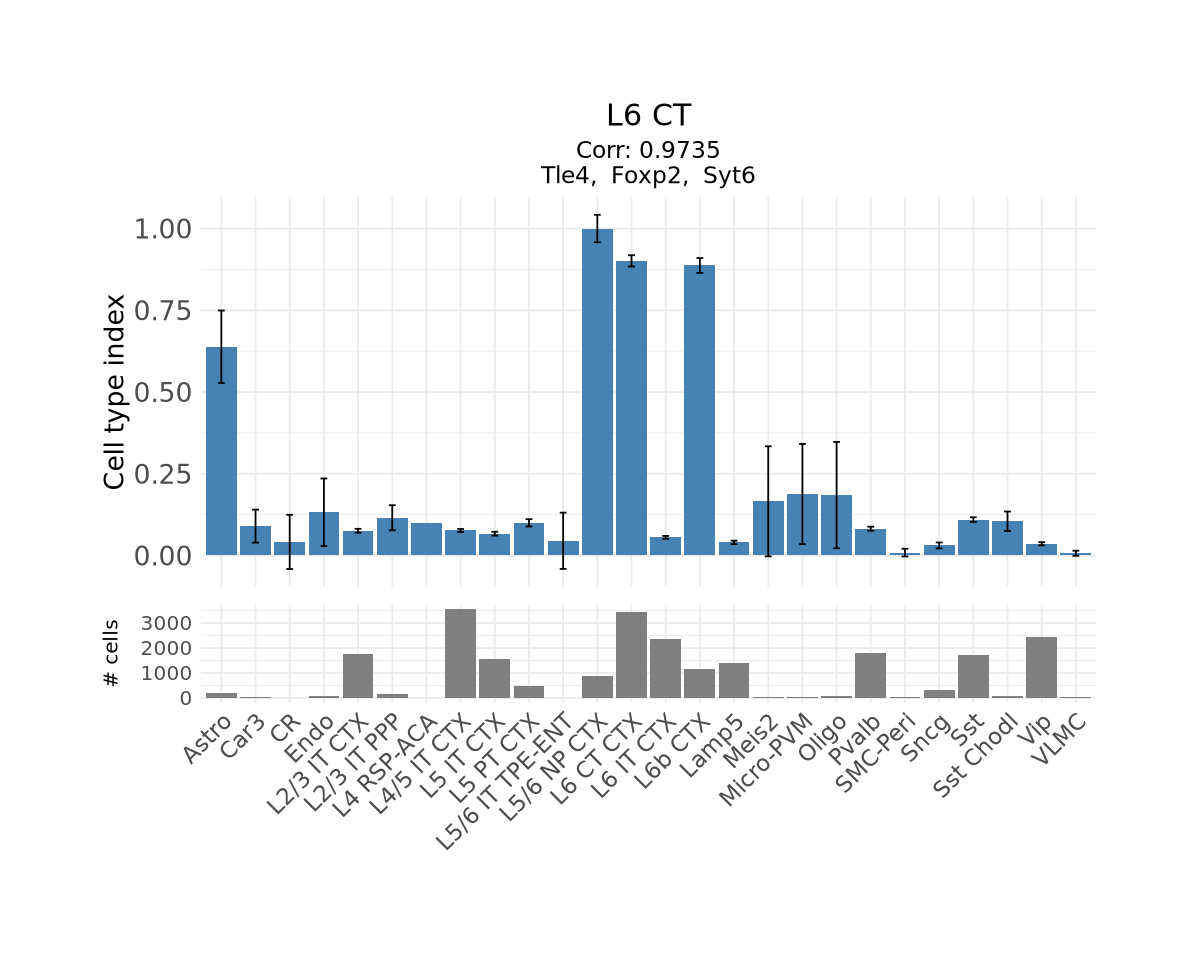

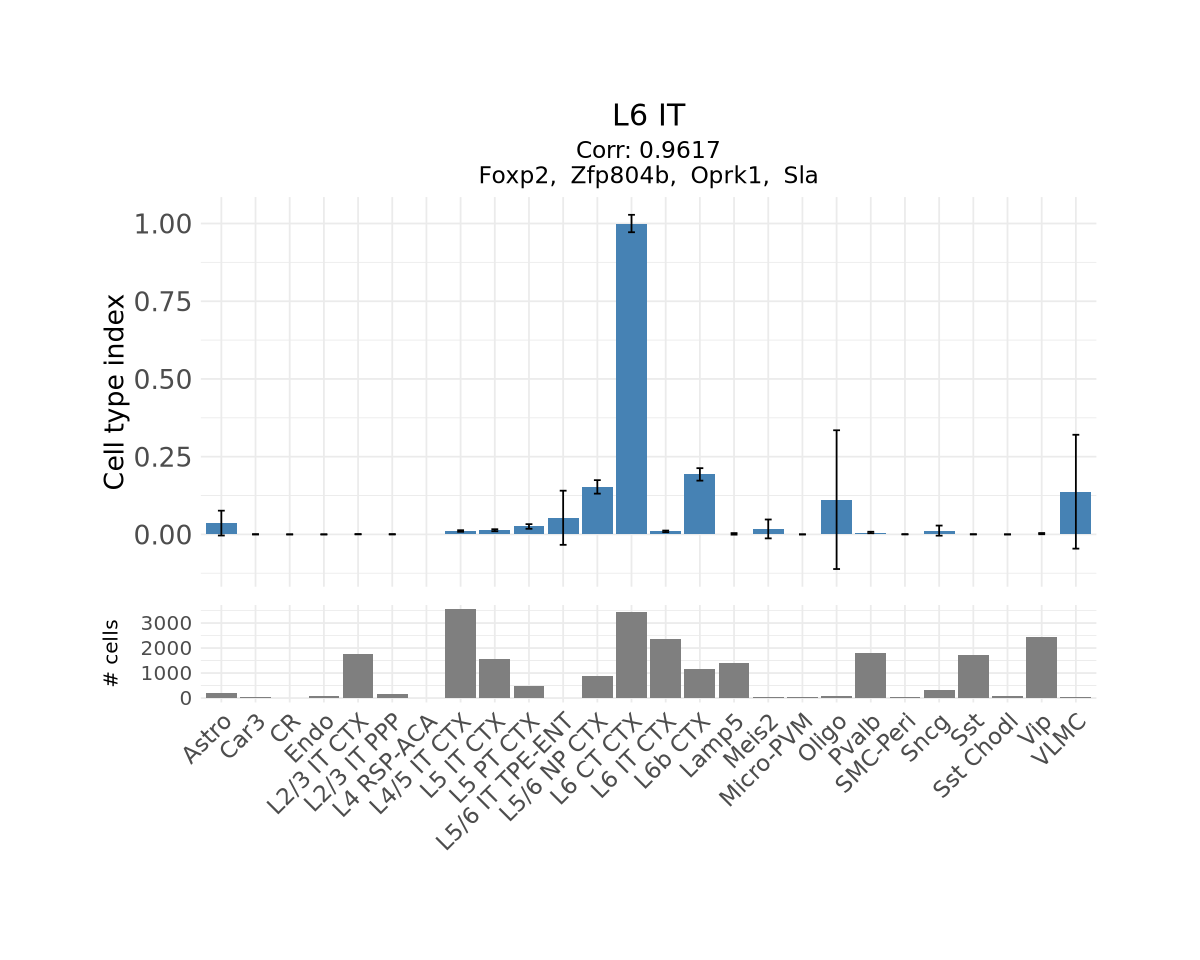

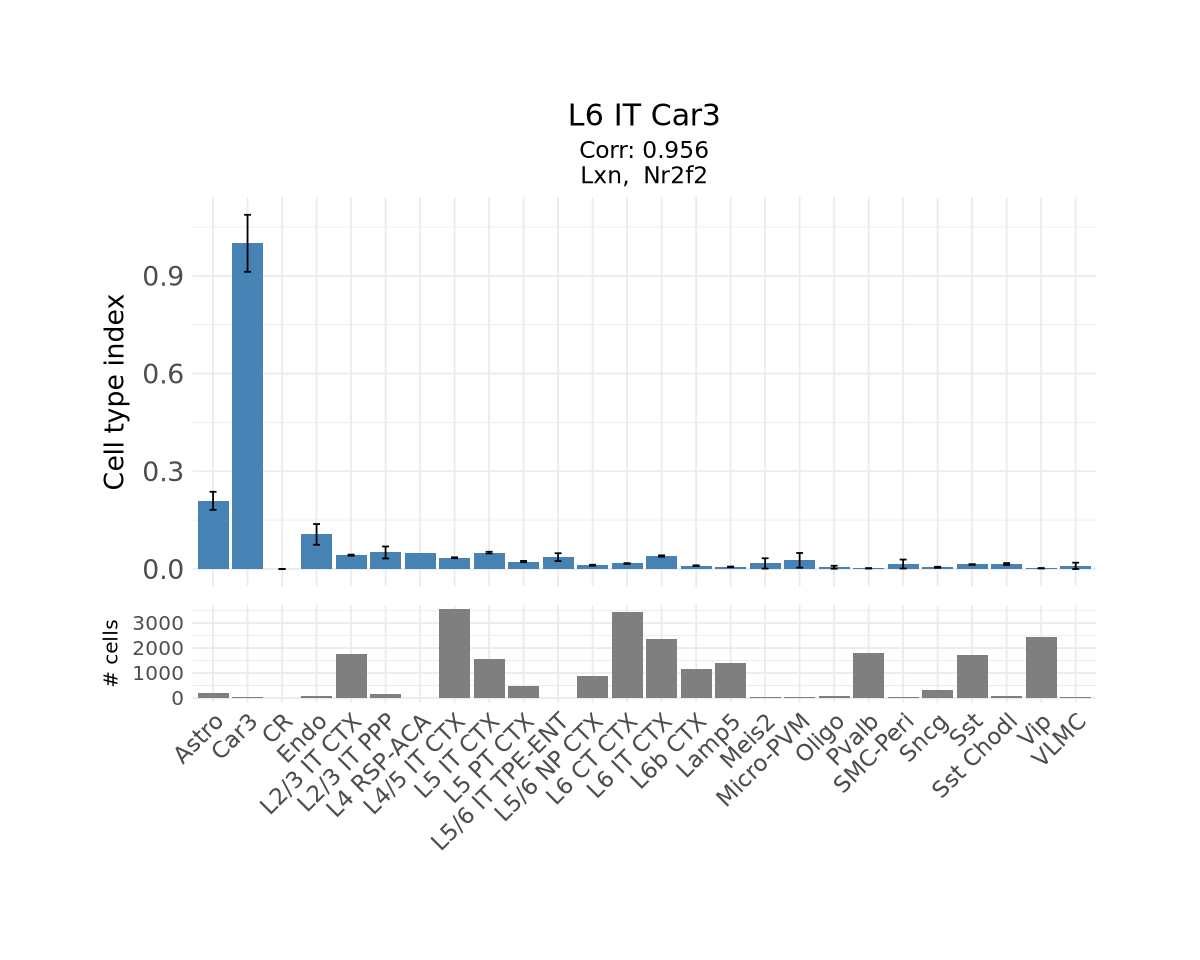

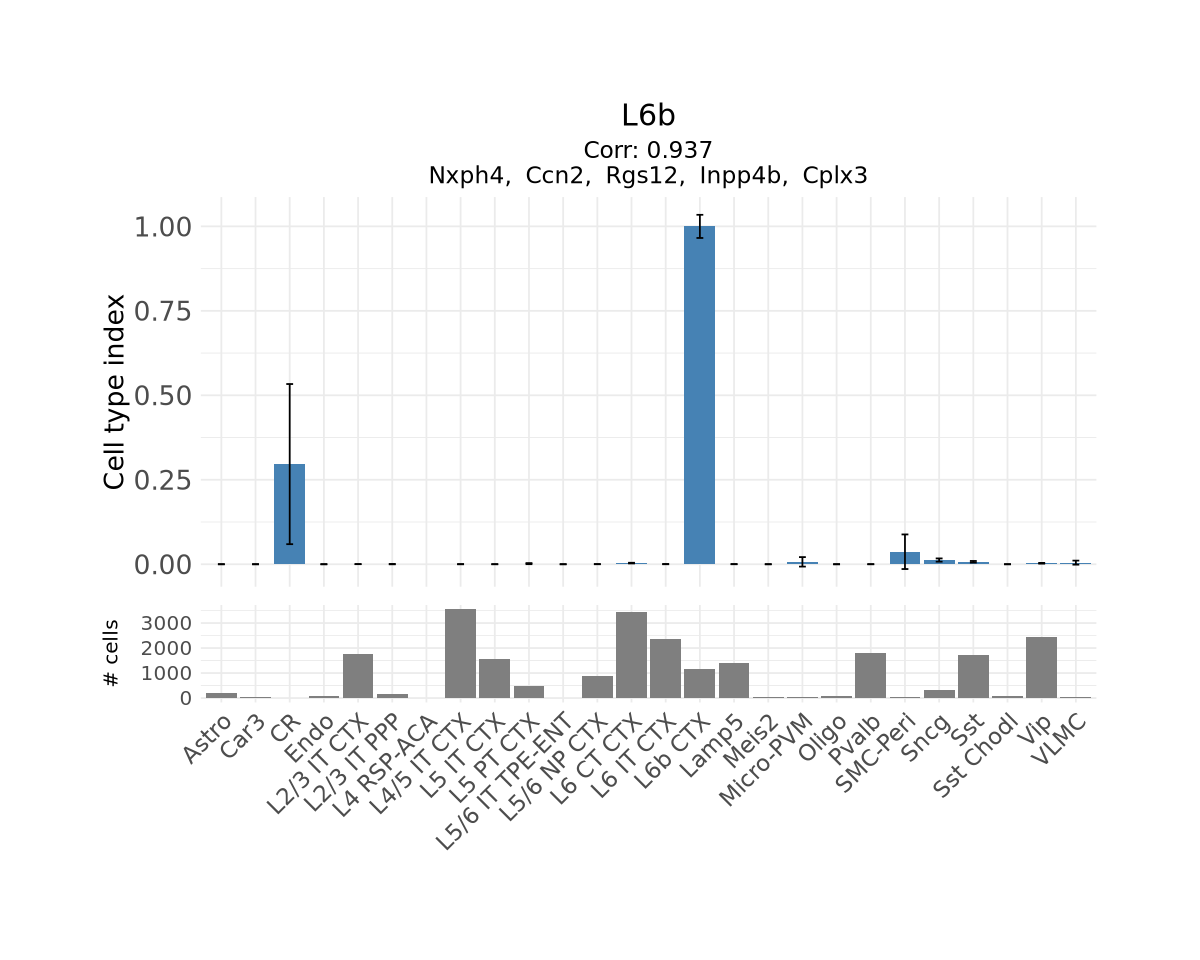

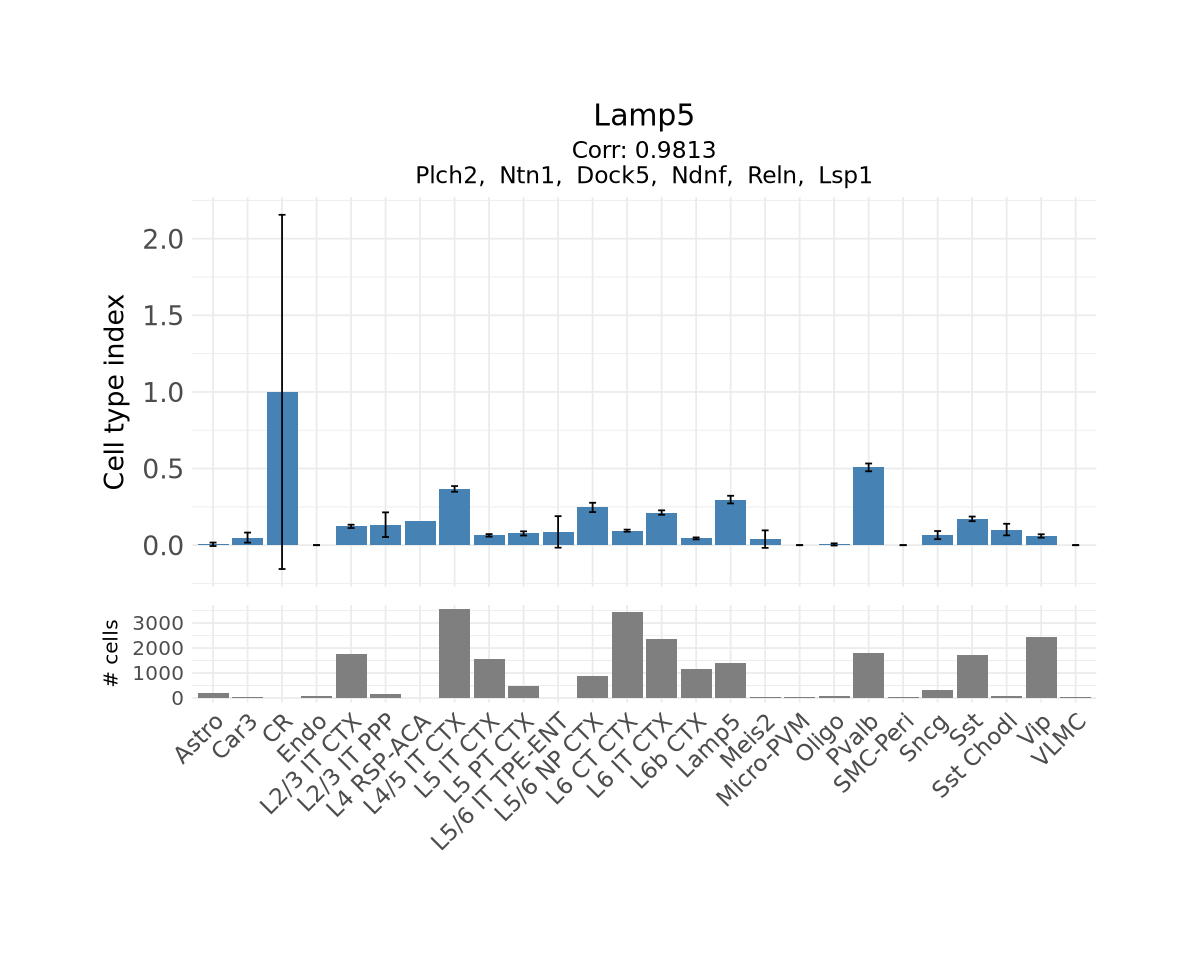

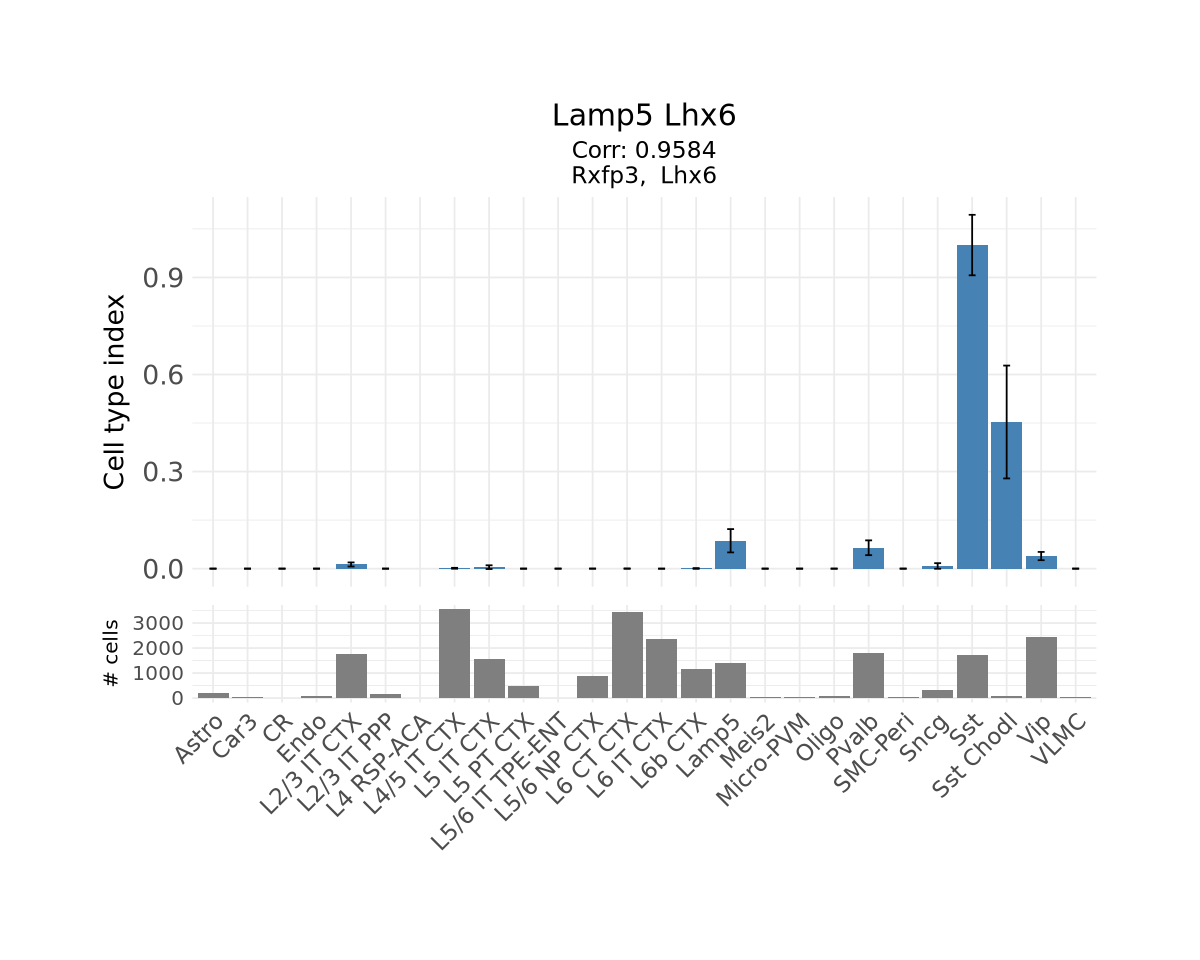

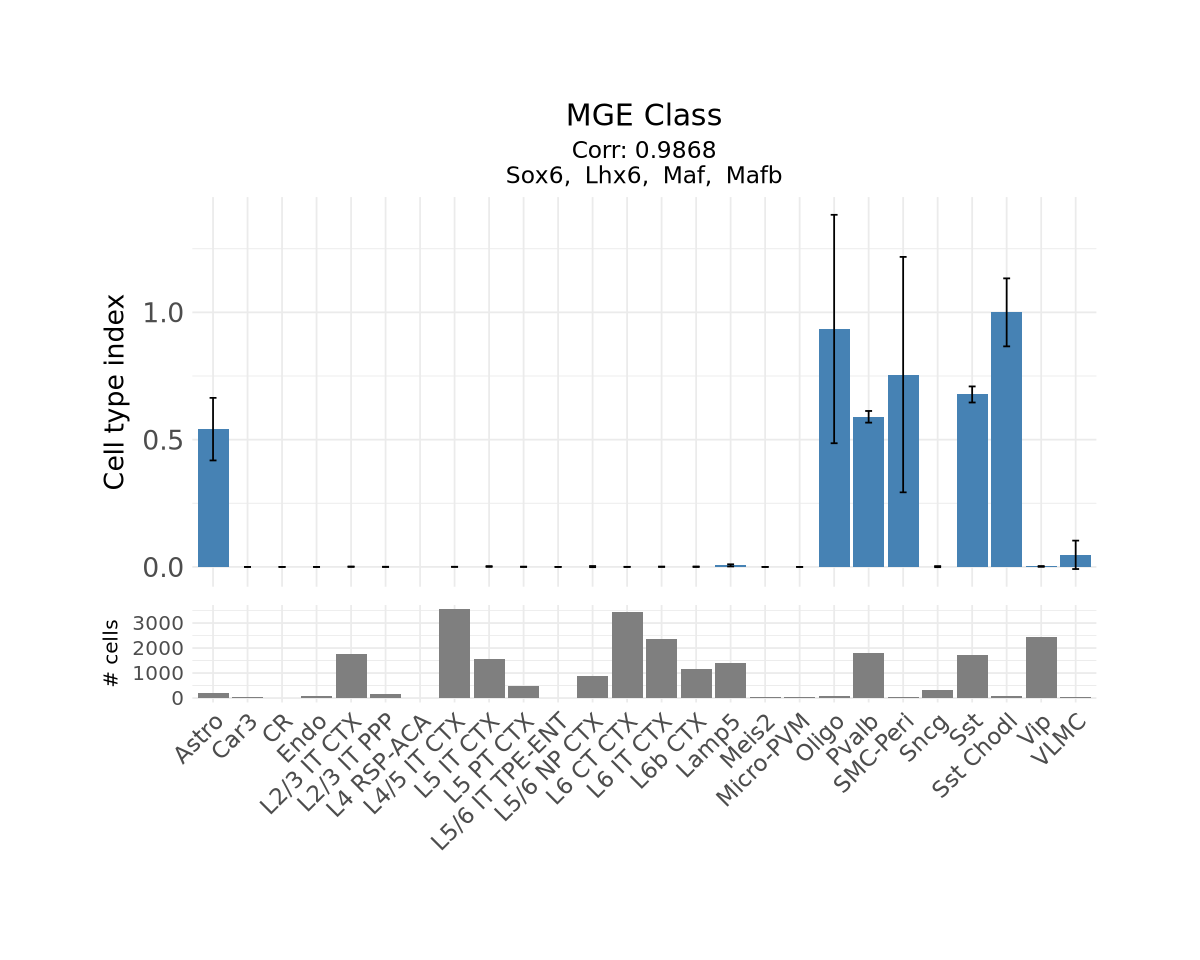

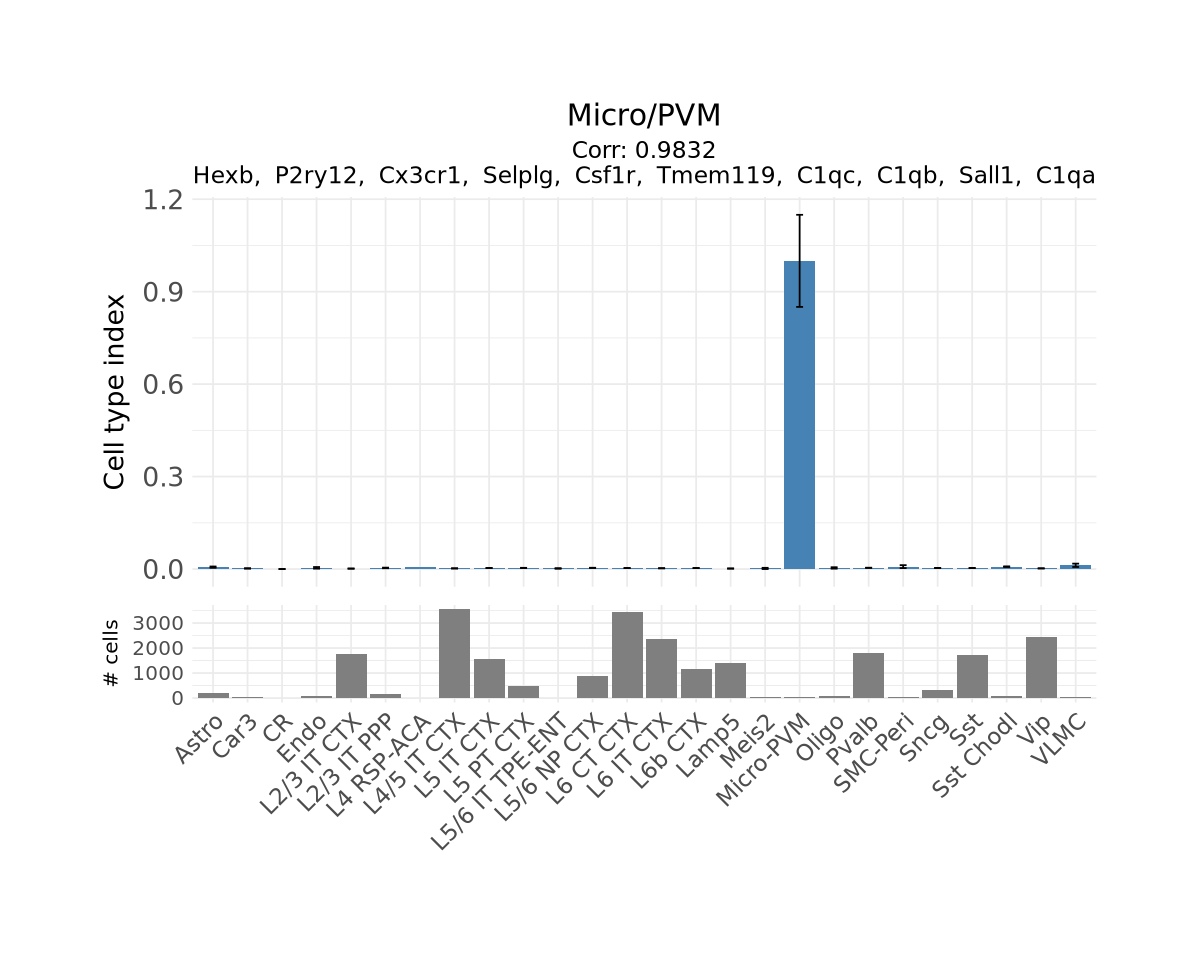

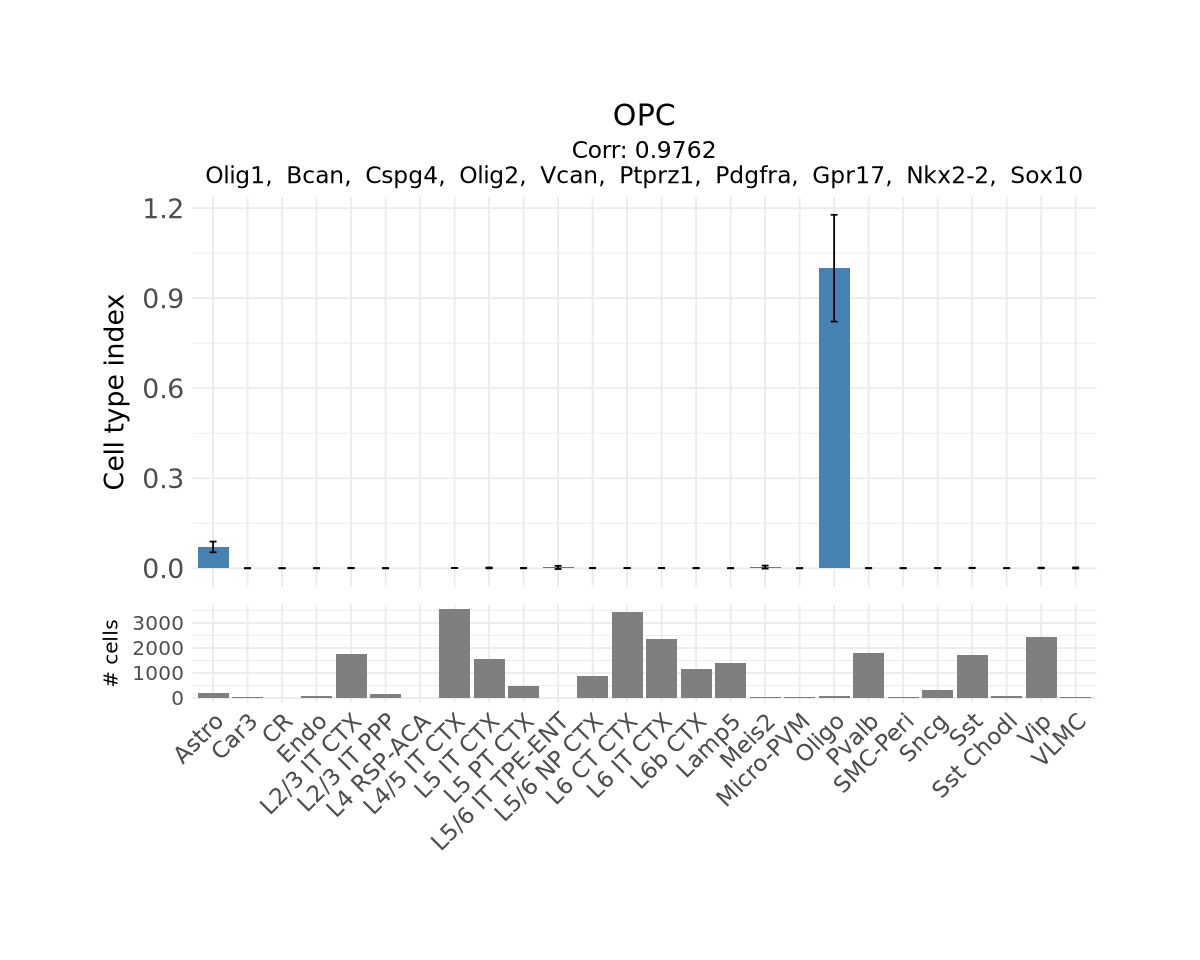

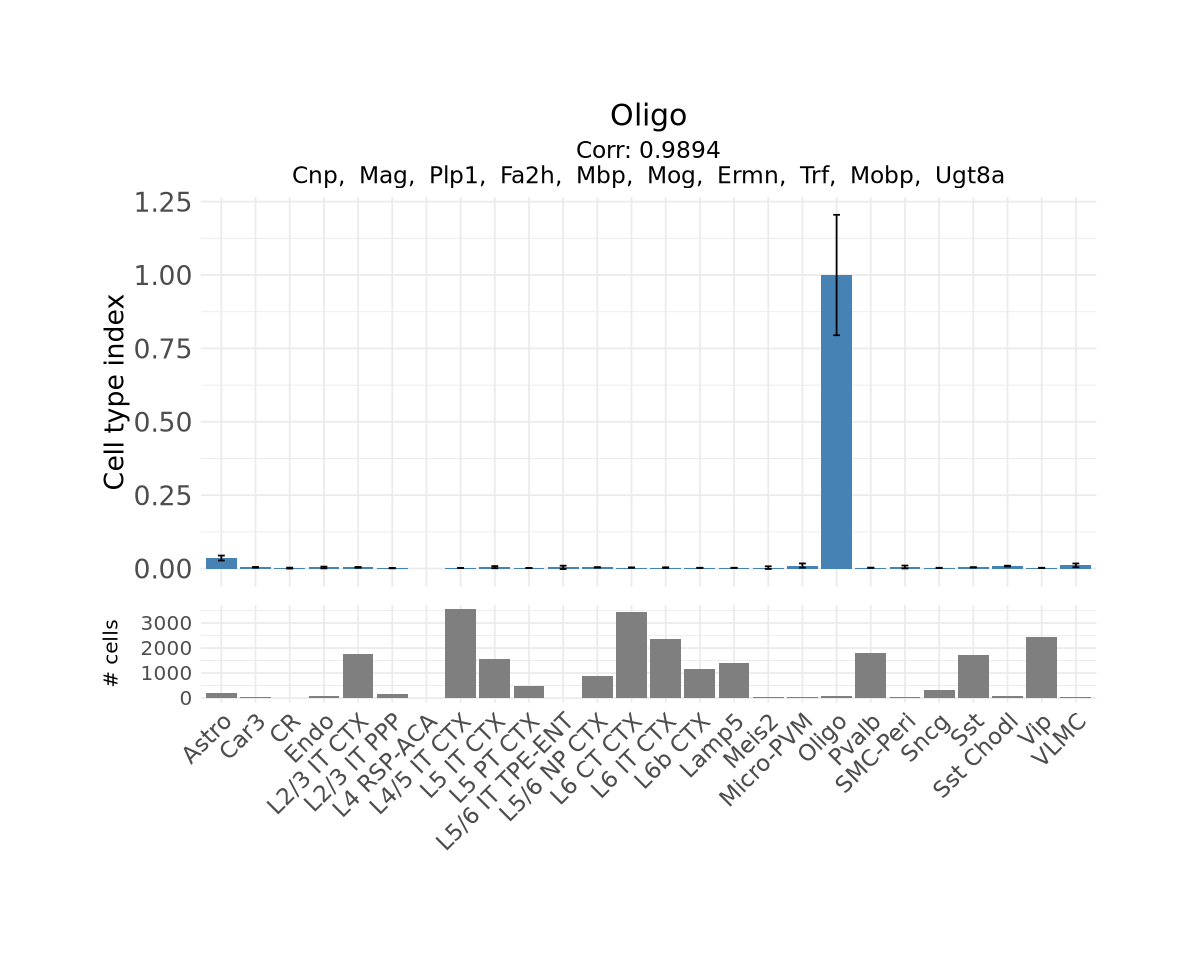

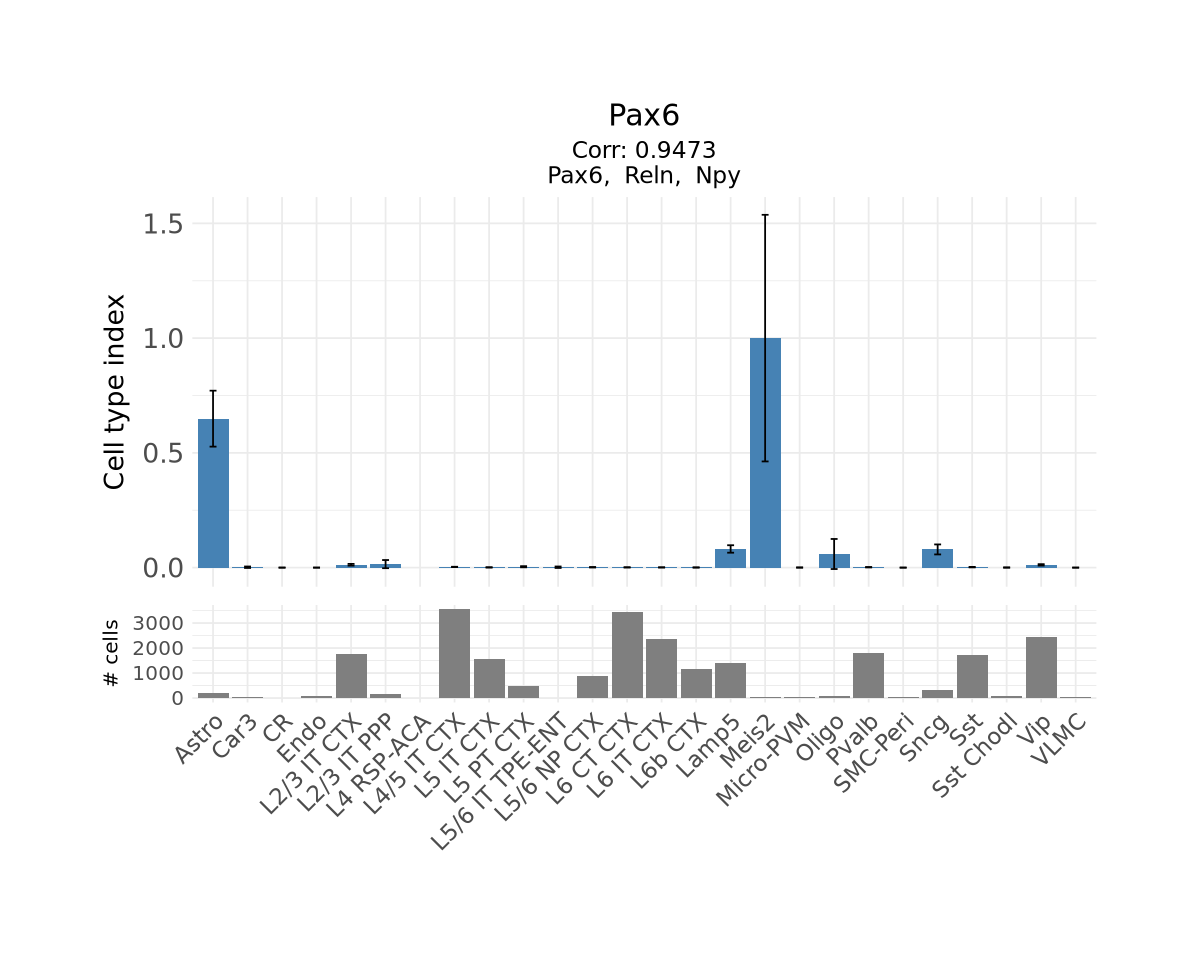

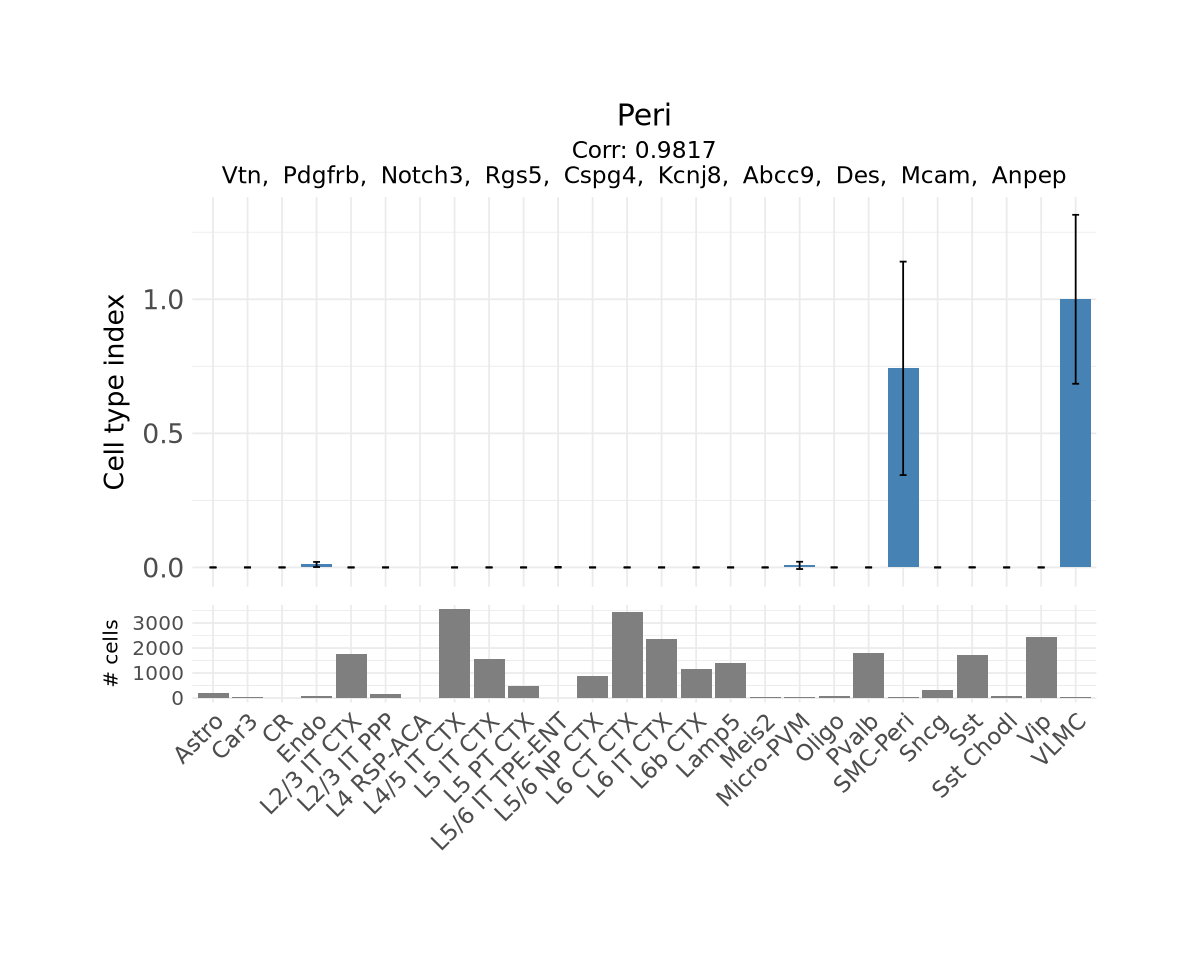

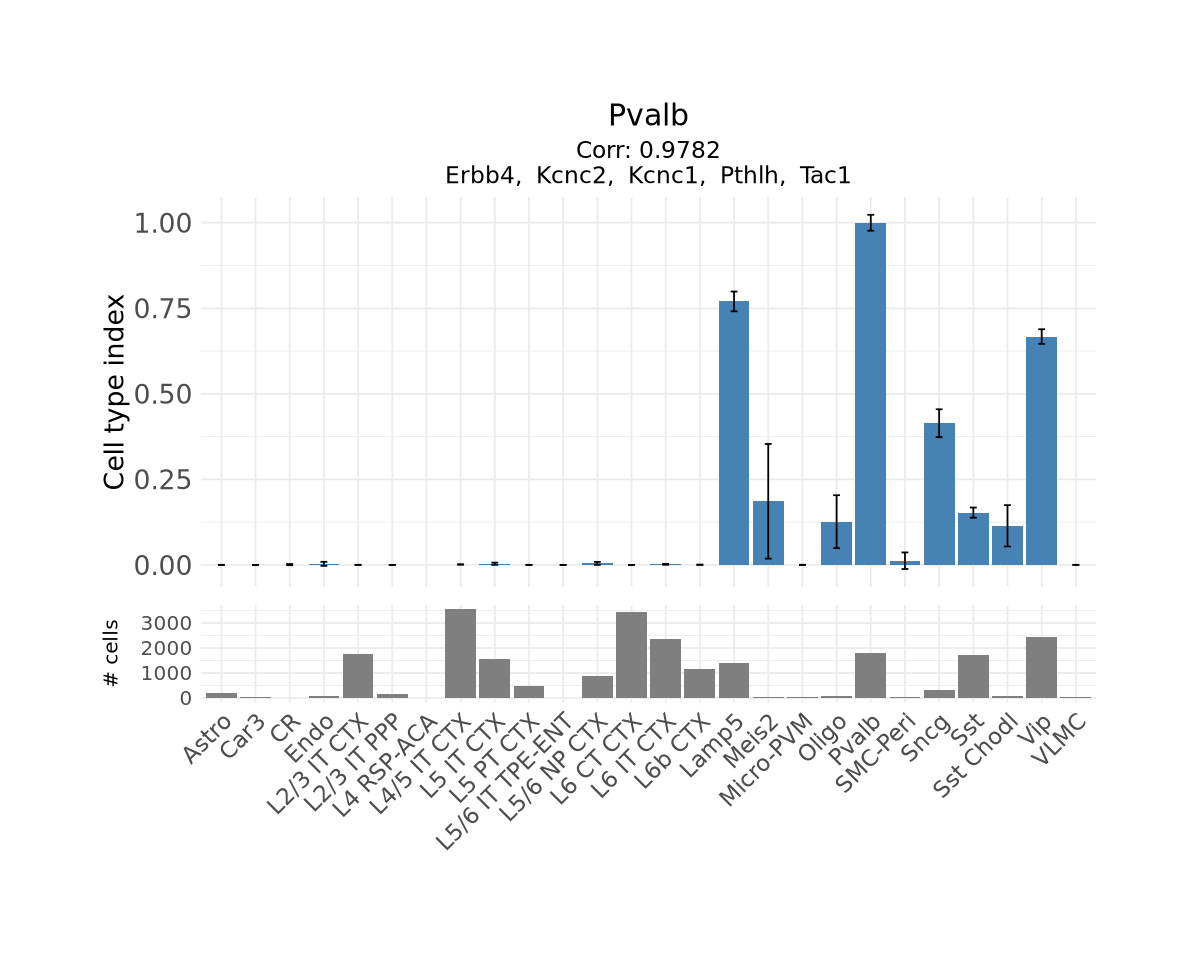

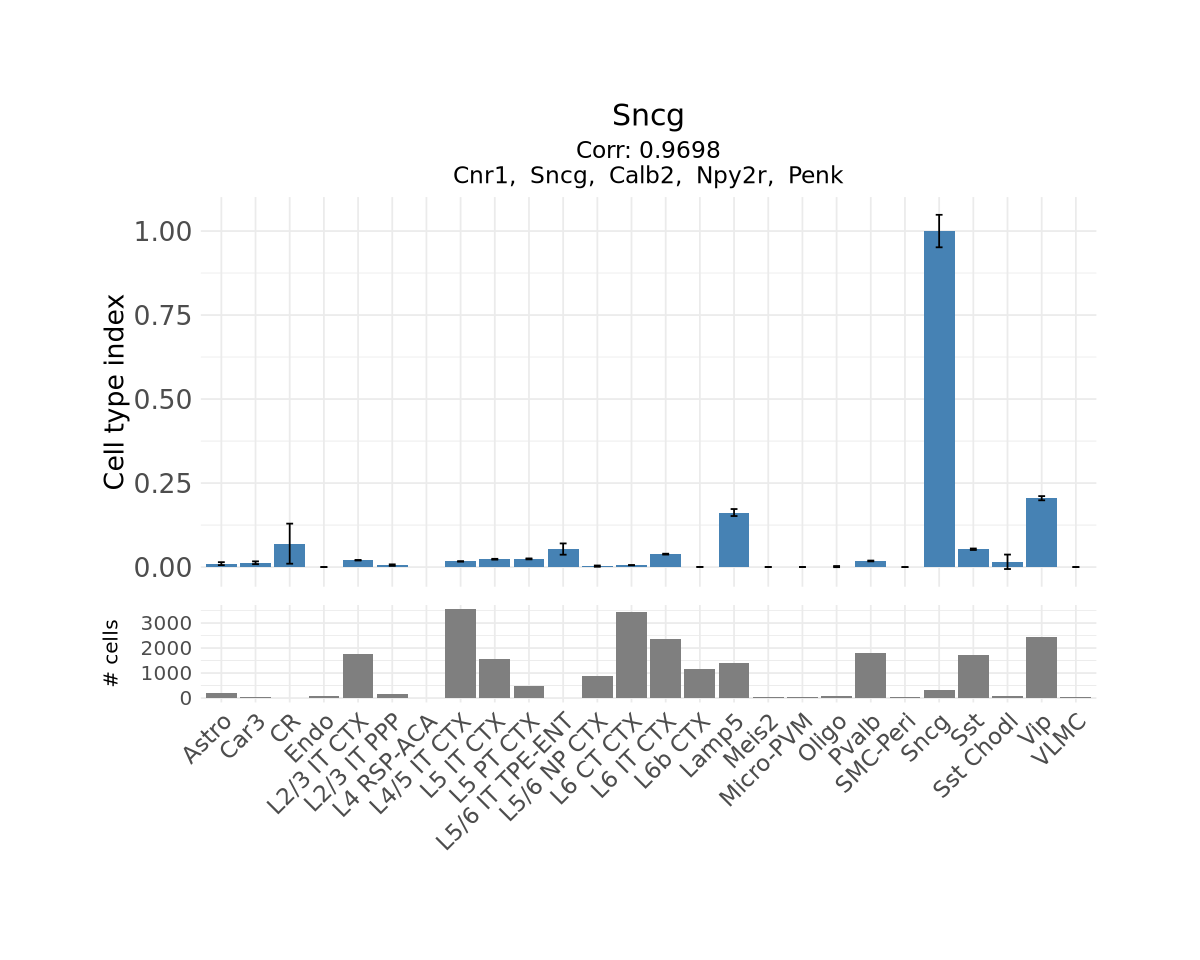

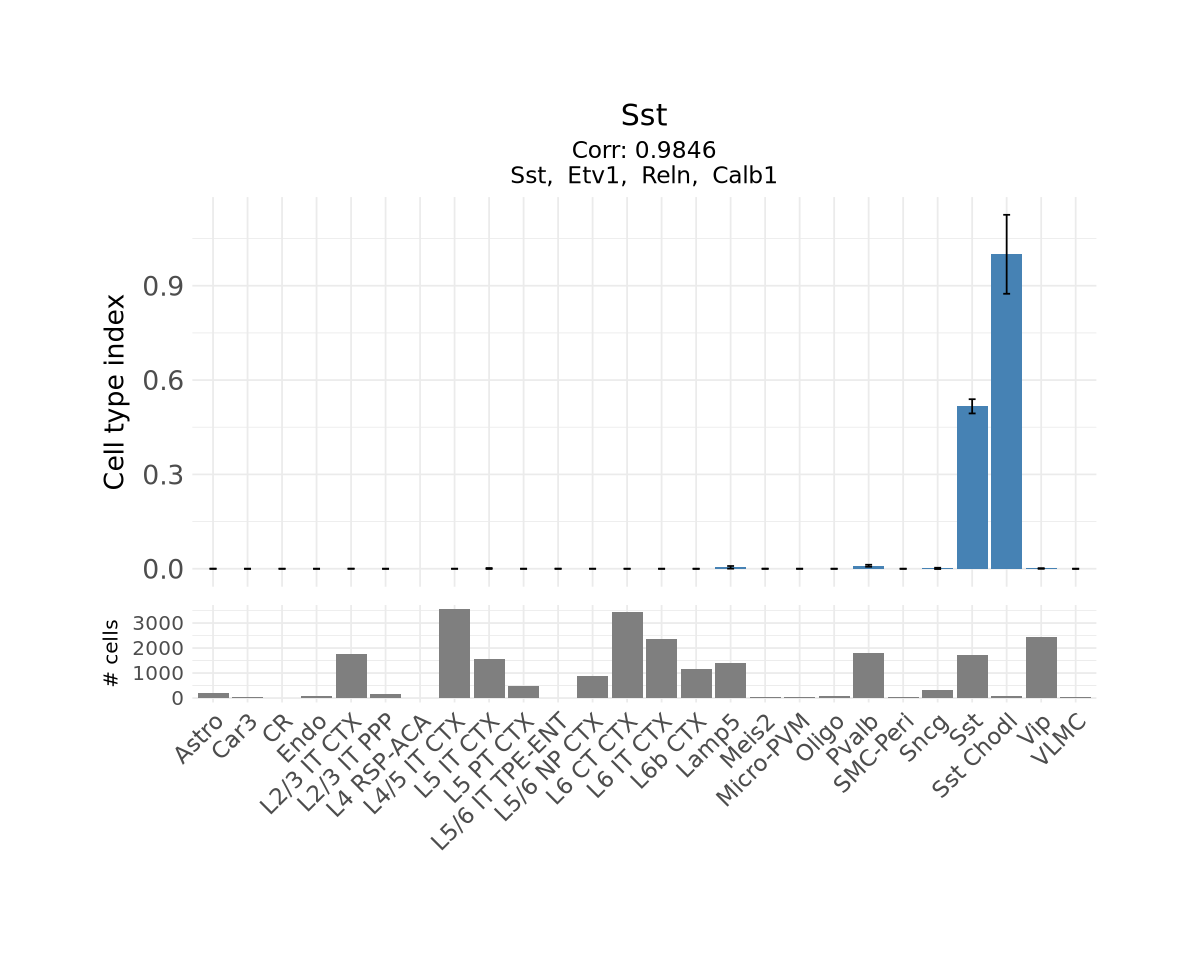

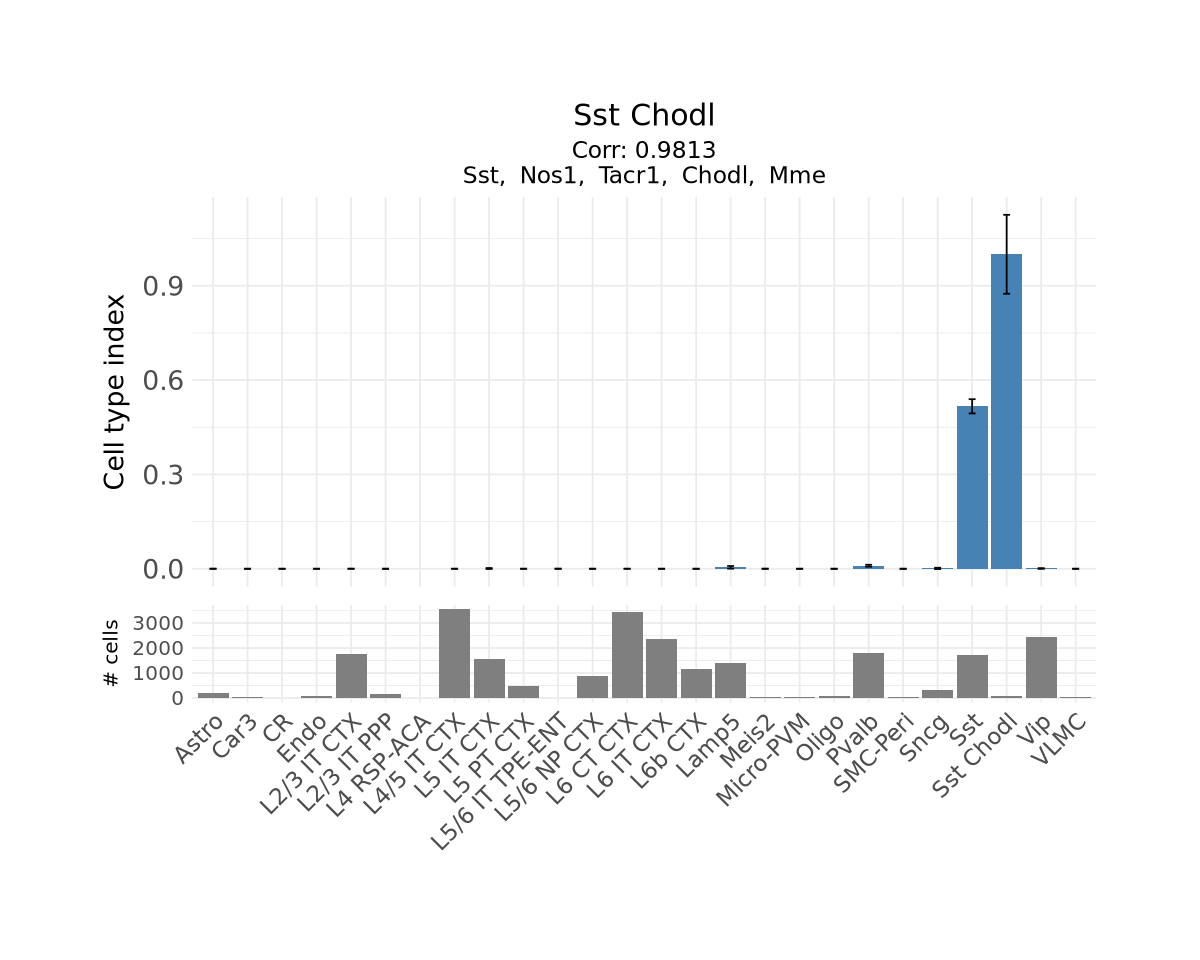

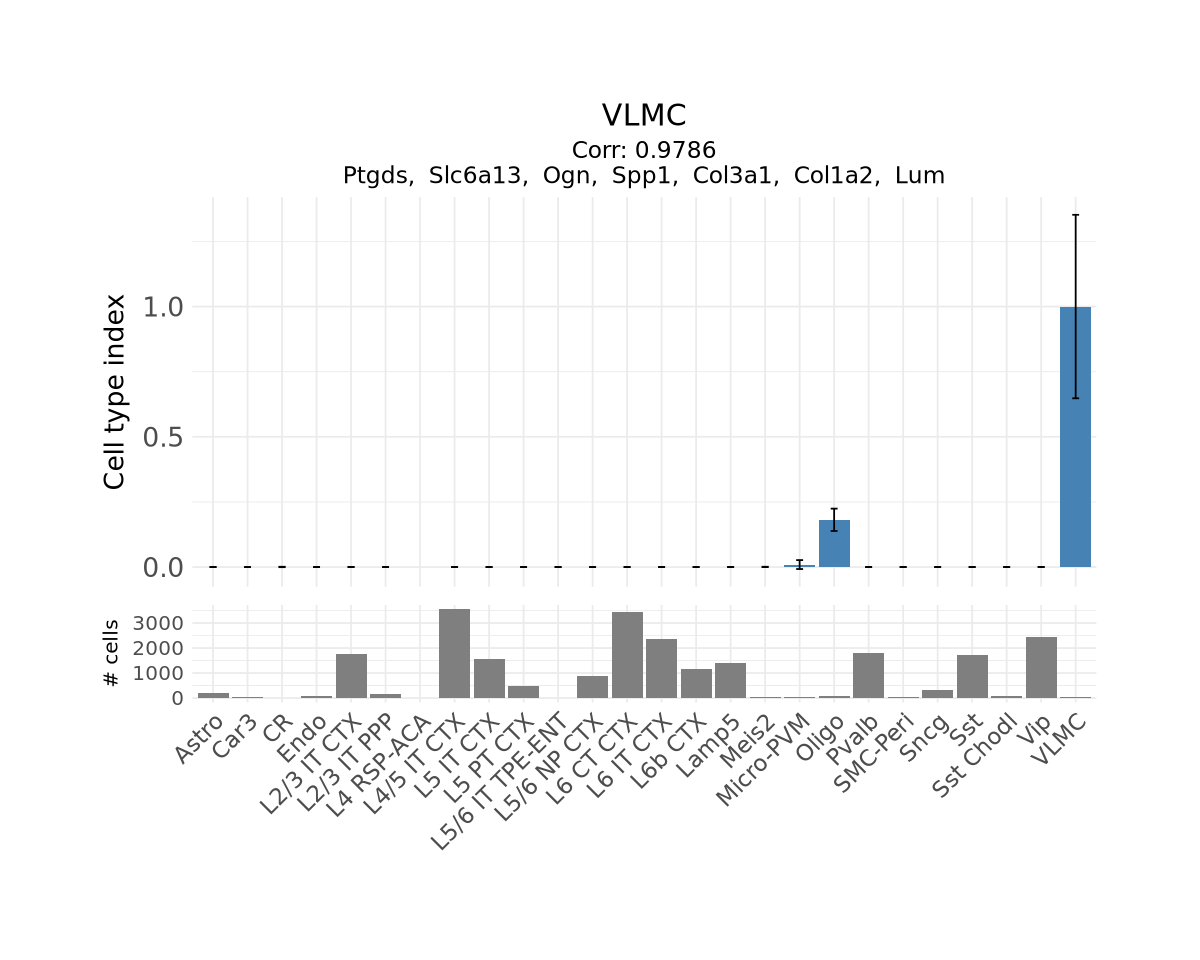

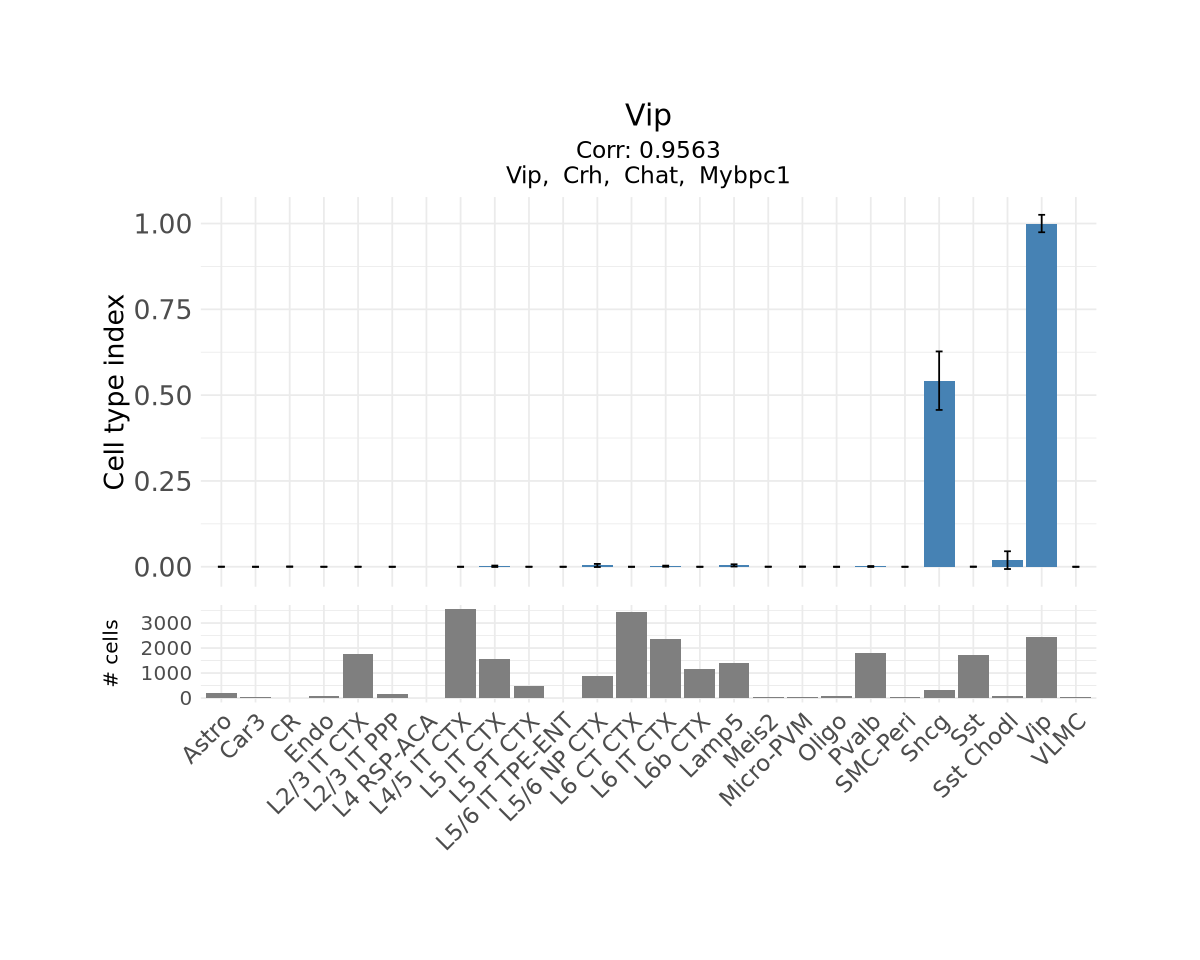

In [101]:
options(repr.plot.width=10, repr.plot.height=8)

for(i in 1:nrow(top_mods_df)) {
    gene_vec <- unlist(lapply(strsplit(top_mods_df$leadingEdge[i], ","), "["))
    plot_title <- top_mods_df$Cell_type[i]
    plot_sub <- paste("Corr:", round(top_mods_df$Corr[i], 4))
    plot_gene_projections(sc_expr, gene_vec, ctype_assignment_vec, plot_title, plot_sub, target_species=NULL)   
}

# Save MEs

In [112]:
modEig_list <- lapply(1:nrow(top_mods_df), function(i) {
    modEig <- fread(top_mods_df$ME_path[i], data.table=FALSE)
    col_idx <- which(colnames(modEig) == top_mods_df$Mod[i]) 
    modEig <- modEig[,c(1, col_idx)]
    colnames(modEig)[2] <- top_mods_df$Cell_type[i]
    modEig 
})


In [115]:
modEig_df <- Reduce(function(x, y) merge(x, y, by="Sample"), modEig_list)

In [ ]:
fwrite(modEig_df, file=paste0("data/", network_dir, "_top_corr_enriched_w_Claude_marker_genes_", summary_type, "_ctype_abundance.csv"), row.names=FALSE)